In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import time
%matplotlib inline
import os
import json
from typing import List, Tuple, Dict, Any
import functools

import pennylane as qml
from pennylane import numpy as np
from pennylane.optimize import spsa
from pennylane.transforms import transform

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [2]:
# set fixed seed to reproduce results
np.random.seed(42)

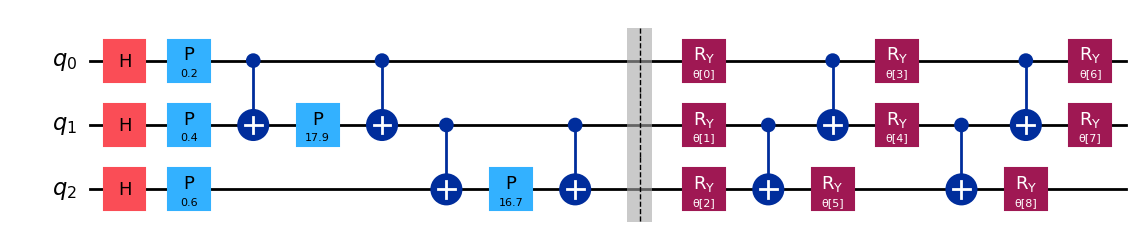

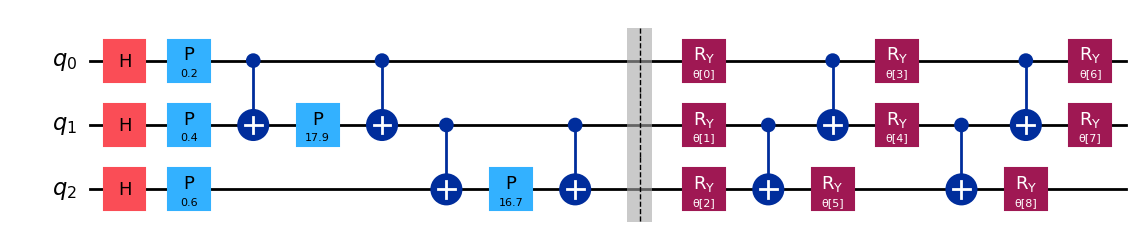

In [3]:
from qiskit.circuit.library import ZZFeatureMap, TwoLocal, RealAmplitudes
from qiskit.circuit import QuantumCircuit

data = [0.1, 0.2, 0.3]

# Feature map: encodes classical data into quantum states
zz_feature_map_reference = ZZFeatureMap(feature_dimension=3, reps=1, entanglement="linear")
zz_feature_map_reference = zz_feature_map_reference.assign_parameters(data)

# Ansatz: RealAmplitudes is a common choice for VQCs
variation_form = RealAmplitudes(num_qubits=3, reps=2)
#variation_form = TwoLocal(3, ["ry", "rz"], "cz", reps=0)

# Combine feature map and ansatz
vqc_ansatz = QuantumCircuit(3)
vqc_ansatz.compose(zz_feature_map_reference, inplace=True)
vqc_ansatz.barrier()
vqc_ansatz.compose(variation_form, inplace=True)
vqc_ansatz.decompose().draw("mpl")

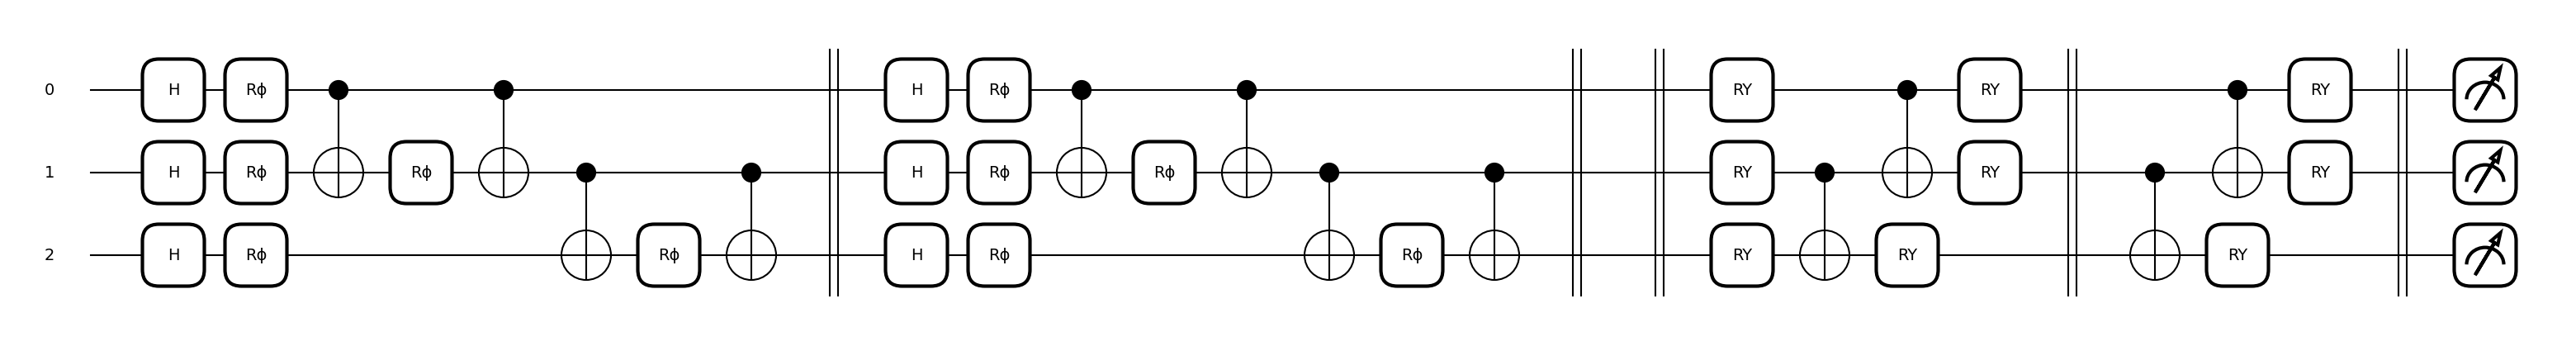

In [44]:
# / ----------------------- \ #
# | FM+Ansatz visualisation | #
# \ ----------------------- / #
qml.drawer.use_style('black_white')  # Optional style

#fig, ax = qml.draw_mpl(qml.transforms.decompose(many_shots_hamming_qvc_circuit), expansion_strategy="device")(np.append(X_train_sampled[0], [0.0]), init_params)
fig, ax = qml.draw_mpl(qml.transforms.decompose(many_shots_hamming_qvc_circuit), expansion_strategy="device")(X_train_sampled[0], init_params)
plt.show()

In [3]:
qml.about()

Name: PennyLane
Version: 0.40.0
Summary: PennyLane is a cross-platform Python library for quantum computing, quantum machine learning, and quantum chemistry. Train a quantum computer the same way as a neural network.
Home-page: https://github.com/PennyLaneAI/pennylane
Author: 
Author-email: 
License: Apache License 2.0
Location: /home/pta0054/it4i/qvsm/venv/lib/python3.10/site-packages
Requires: appdirs, autograd, autoray, cachetools, diastatic-malt, networkx, numpy, packaging, pennylane-lightning, requests, rustworkx, scipy, tomlkit, typing-extensions
Required-by: PennyLane-qiskit, PennyLane_Lightning

Platform info:           Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.35
Python version:          3.10.12
Numpy version:           2.0.2
Scipy version:           1.15.1
Installed devices:
- qiskit.aer (PennyLane-qiskit-0.40.0)
- qiskit.basicaer (PennyLane-qiskit-0.40.0)
- qiskit.basicsim (PennyLane-qiskit-0.40.0)
- qiskit.remote (PennyLane-qiskit-0.40.0)
- default.clifford 

In [4]:
# --- Qiskit imports (modern runtime API) ---
#from qiskit_ibm_runtime import QiskitRuntimeService
#from qiskit_aer.noise import NoiseModel
#from qiskit_ibm_runtime.fake_provider import FakeBrisbane

#backend = FakeBrisbane()

# Build a realistic noise model from it
#noise_model = NoiseModel.from_backend(backend)


# Definitions

In [5]:
def load_data(input_file: str, header: List[str] = []) -> pd.DataFrame:
    if header:
        df = pd.read_csv(input_file, names=header)
    else:
        df = pd.read_csv(input_file)
    return df

def preprocess_data(df: pd.DataFrame, y_mapping: Dict[Any, Any], y_column: str, PCA_number_of_components: int) -> Tuple[Tuple[np.ndarray, pd.Series], Tuple[np.ndarray, pd.Series]]:
    # Features (X) and target (y)
    X = df.drop(columns=y_column)  # features (all columns except target)
    y = df[y_column]               # target/class feature
    
    # scaling the labels to -1, 1 is important for the SVM and the definition of a hinge loss
    y = y.map(y_mapping)

    # Split the dataset: 80% training, 20% testing
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    print("Train set size:", X_train.shape)
    print("Test set size:", X_test.shape)

    ## --- Scale Data --- ## 
    # Initialize the scaler
    scaler = StandardScaler()
    
    # Fit the scaler on training data, transform both training and testing data
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("--- Mean Scaler ---")
    print("Mean of scaled features (should be ~0):", np.mean(X_train_scaled, axis=0))
    print("Std of scaled features (should be ~1):", np.std(X_train_scaled, axis=0))
    print()
    
    # Initialize PCA to reduce to 2 principal components
    pca = PCA(n_components=PCA_number_of_components)
    
    # Fit PCA on the *scaled* training data and transform both train/test sets
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    print("--- PCA ---")
    print("Train set size after PCA:", X_train_pca.shape)
    print("Test set size after PCA:", X_test_pca.shape)
    print("Explained variance ratio:", pca.explained_variance_ratio_)
    print("Total variance explained by 2 components:", sum(pca.explained_variance_ratio_))
    print()
    
    # Visualize the obtained components
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', alpha=0.6)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('PCA Projection (2D)')
    plt.colorbar(label='Target')
    plt.show()

    # Initialize MinMaxScaler to scale features between 0 and 1
    minmax_scaler = MinMaxScaler()
    
    # Fit on PCA-transformed training data and transform both train/test
    X_train_final = minmax_scaler.fit_transform(X_train_pca)
    X_test_final = minmax_scaler.transform(X_test_pca)

    print("--- Min-Max Scaler ---")
    print("Min value per feature (should be 0):", X_train_final.min(axis=0))
    print("Max value per feature (should be 1):", X_train_final.max(axis=0))
    print()

    # make non trainable
    X_train_final = np.array(X_train_final, requires_grad=False)
    X_test_final = np.array(X_test_final, requires_grad=False)
    y_train = np.array(y_train, requires_grad=False)
    y_test = np.array(y_test, requires_grad=False)

    return ((X_train_final, y_train), (X_test_final, y_test))

# Hyperparameters setting

In [6]:
n_qubits = 3
n_reps_fm = 1
n_reps_ansatz = 2
data_reupload = "Full" # Full, Partial(default)
dataset = "C"


In [7]:
trained_on_model = 1
weights_file = f"w_qubits={n_qubits}_layersFM={n_reps_fm}_layersAnsatz={n_reps_ansatz}_DataReupload={data_reupload}_Dataset={dataset}_trained={trained_on_model}.v2.npy"
results_file = f"r_qubits={n_qubits}_layersFM={n_reps_fm}_layersAnsatz={n_reps_ansatz}_DataReupload={data_reupload}_Dataset={dataset}_trained={trained_on_model}.v2.csv"
training_history_file = f"h_qubits={n_qubits}_layersFM={n_reps_fm}_layersAnsatz={n_reps_ansatz}_DataReupload={data_reupload}_Dataset={dataset}_trained={trained_on_model}.v2.json"
training_history_plot_file = f"h_qubits={n_qubits}_layersFM={n_reps_fm}_layersAnsatz={n_reps_ansatz}_DataReupload={data_reupload}_Dataset={dataset}_trained={trained_on_model}.v2.pdf"

# Dataset loading

In [8]:
# Choose dataset

# A, Heart Failure Prediction
if dataset == "A":
    print(f"Chosen dataset: A, Heart Failure Prediction")
    df = load_data(os.path.join("datasets", "Heart Failure Prediction", "heart_failure_clinical_records_dataset.csv"))
# B, Pima Indians Diabetes Database
elif dataset == "B":
    print(f"Chosen dataset: B, Pima Indians Diabetes Database")
    df = load_data(os.path.join("datasets", "Pima Indians Diabetes Database", "diabetes.csv"))
# C, Breast Cancer Wisconsin
elif dataset == "C":
    print(f"Chosen dataset: C, Breast Cancer Wisconsin")
    df = load_data(os.path.join("datasets", "Breast Cancer Wisconsin (Diagnostic)", "wdbc.data"), header=["id","diagnosis","radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean","compactness_mean","concavity_mean","concave points_mean","symmetry_mean","fractal_dimension_mean","radius_se","texture_se","perimeter_se","area_se","smoothness_se","compactness_se","concavity_se","concave points_se","symmetry_se","fractal_dimension_se","radius_worst","texture_worst","perimeter_worst","area_worst","smoothness_worst","compactness_worst","concavity_worst","concave points_worst","symmetry_worst","fractal_dimension_worst",])
else:
    raise Exception(f"Unknown dataset: {dataset}")

print(f"Dataframe shape: {df.shape}")
df.head()

Chosen dataset: C, Breast Cancer Wisconsin
Dataframe shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
if dataset == "A":
    print(f"Targets: {df['DEATH_EVENT'].unique()}")
# B, Pima Indians Diabetes Database
elif dataset == "B":
    print(f"Targets: {df['Outcome'].unique()}")
# C, Breast Cancer Wisconsin
elif dataset == "C":
    print(f"Targets: {df['diagnosis'].unique()}")
else:
    raise Exception(f"Unknown dataset: {dataset}")

Targets: ['M' 'B']


Train set size: (455, 31)
Test set size: (114, 31)
--- Mean Scaler ---
Mean of scaled features (should be ~0): [ 0.00000000e+00 -3.16230558e-16 -3.51367287e-17 -1.13218348e-16
  3.66983611e-16 -2.38148939e-16 -4.29448906e-17 -5.95372347e-17
  2.22532615e-16  1.44450996e-16  5.05578485e-16  9.56499837e-17
  7.02734574e-17  2.83045870e-16  6.24652955e-17 -7.80816193e-18
 -1.52259158e-16  2.14724453e-17 -2.14724453e-16 -1.91299967e-16
  2.24484656e-16 -7.02734574e-17 -6.75406007e-16 -2.92806072e-17
  1.81539765e-16 -1.56163239e-17 -2.24972666e-16 -7.61295788e-17
 -8.19857003e-17  5.15338687e-16  2.14724453e-17]
Std of scaled features (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1.]

--- PCA ---
Train set size after PCA: (455, 3)
Test set size after PCA: (114, 3)
Explained variance ratio: [0.42132688 0.18887304 0.09556973]
Total variance explained by 2 components: 0.7057696576239375



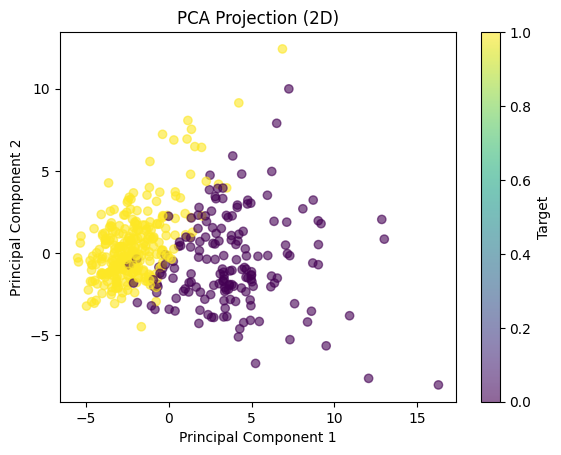

--- Min-Max Scaler ---
Min value per feature (should be 0): [0. 0. 0.]
Max value per feature (should be 1): [1. 1. 1.]



In [10]:
# Divide data into train and test split
# A,
if dataset == "A":
    (X_train, y_train), (X_test, y_test) = preprocess_data(df, y_mapping={1: 1, 0: 0}, y_column="DEATH_EVENT", PCA_number_of_components=n_qubits)
# B,
elif dataset == "B":
    (X_train, y_train), (X_test, y_test) = preprocess_data(df, y_mapping={1: 1, 0: 0}, y_column="Outcome", PCA_number_of_components=n_qubits)
# C,
elif dataset == "C":
    (X_train, y_train), (X_test, y_test) = preprocess_data(df, y_mapping={'M': 0, 'B': 1}, y_column="diagnosis", PCA_number_of_components=n_qubits)

In [11]:
# Take only some portion of data
each_nth = 1 # 1 = all data

X_train_sampled = X_train[::each_nth]
y_train_sampled = y_train[::each_nth]
X_test_sampled = X_test[::each_nth]
y_test_sampled = y_test[::each_nth]

print(f"Size of sampled dataset: {X_train_sampled.shape}. Fraction of the input dataset: {X_train_sampled.shape[0] / X_train.shape[0]}")

Size of sampled dataset: (455, 3). Fraction of the input dataset: 1.0


# Model definition and training

## Shared parts

In [12]:
# Some shared definitions

# plot pennylane circuit
def draw_circuit(circuit, fontsize=20, style='pennylane', scale=None, title=None, decimals=2, level=None):
    def _draw_circuit(*args, **kwargs):
        nonlocal circuit, fontsize, style, scale, title, level
        qml.drawer.use_style(style)
        fig, ax = qml.draw_mpl(circuit, decimals=decimals, level=level)(*args, **kwargs)
        if scale is not None:
            dpi = fig.get_dpi()
            fig.set_dpi(dpi*scale)
        if title is not None:
            fig.suptitle(title, fontsize=fontsize)
        plt.show()
    return _draw_circuit
    
# plot training cost and accuracy history
def plot_history(history, ansatz_layers, fm_layers, n_shots, n_qubits, dataset, data_reuploading, output_file):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # --- First subplot with dual y-axes ---
    ax1_loss = ax1
    ax1_acc = ax1.twinx()  # create a second y-axis for accuracy
    
    # Plot cost function (left y-axis)
    ax1_loss.plot(history["train_loss"]["avg"], marker='o', linestyle='-', color='b', label='Cost function')
    ax1_loss.set_ylabel('Train cost function value', color='b')
    ax1_loss.tick_params(axis='y')
    
    # Plot accuracy (right y-axis)
    ax1_acc.plot(history["train_avg_scores"]["Accuracy"], marker='x', linestyle='--', color='g', label='Train accuracy')
    ax1_acc.plot(history["train_avg_scores"]["Precision"], marker='s', linestyle='--', color='g', label='Train precision')
    ax1_acc.plot(history["train_avg_scores"]["F1"], marker='^', linestyle='--', color='g', label='Train F1 score')
    ax1_acc.set_ylabel('Train dataset metrics', color='g')
    ax1_acc.tick_params(axis='y')
    ax1_acc.set_ylim(0, 1)
    
    # Title & legend
    ax1_loss.set_title(f'Dataset={dataset}, Qubits={n_qubits}, Shots={n_shots}, Ansatz layers={ansatz_layers}, Feature map layers={fm_layers}, Data reuploading={data_reuploading}')
    ax1_loss.grid(True)
    #ax1_loss.set_ylim(3, None)
    
    # If you want a combined legend from both axes
    lines_loss, labels_loss = ax1_loss.get_legend_handles_labels()
    lines_acc, labels_acc = ax1_acc.get_legend_handles_labels()
    ax1_loss.legend(lines_loss + lines_acc, labels_loss + labels_acc, loc='lower right')

    # Plot average number of repetitions on the second subplot
    ax2.plot(history["train_exec"]["avg"], marker='s', linestyle='--', color='blue', label='Avg repetitions')
    ax2.plot(history["train_exec"]["max"], marker='s', linestyle='--', color='red', label='Max repetitions')
    ax2.plot(history["train_exec"]["min"], marker='s', linestyle='--', color='green', label='Min repetitions')

    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Number of repetitions statistics.')
    ax2.legend(loc='upper right')
    ax2.grid(True)

    # Save the plot to a PDF
    title = f"Training History, Qubits={n_qubits}, Shots={n_shots}, Ansatz layers={ansatz_layers}, Feature map layers={fm_layers}"
    if os.path.exists(f'results/{output_file}'):
        print(f"Path already exists")
    else:
        plt.savefig(f'results/{output_file}', format='pdf', bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()

In [13]:
# Build the feature map and ansatz
def zz_feature_map(x):
    for _ in range(n_reps_fm):
        for i in range(n_qubits):
            qml.Hadamard(wires=i)
            qml.PhaseShift(2.0 * x[..., i], wires=i)
        # LINEAR entanglement
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
            qml.PhaseShift(2.0 * (np.pi - x[..., i]) * (np.pi - x[..., i+1]), wires=i+1)
            qml.CNOT(wires=[i, i+1])
        qml.Barrier()


def ansatz_real_amplitudes(weights, _):
    # Initial encoding + rotations
    for j in range(n_qubits):
            qml.RY(weights[0, j], wires=j)

    # Repeated layers
    for i in range(n_reps_ansatz):
        # Entanglement: reverse-linear
        for j in range(n_qubits - 1, 0, -1):
            qml.CNOT(wires=[j - 1, j])
        for j in range(n_qubits):
            qml.RY(weights[i+1, j], wires=j)
        qml.Barrier()

def ansatz_real_amplitudes_full_reuploading(weights, x):
    # Initial encoding + rotations
    for j in range(n_qubits):
        qml.RY(weights[0, j], wires=j)  # data re-uploaded in angle
    
    # Repeated layers
    for i in range(n_reps_ansatz):
        # Data reuploading
        for j in range(n_qubits):
            qml.RY(x[..., j], wires=j)
        
        # Entanglement: reverse-linear
        for j in range(n_qubits - 1, 0, -1):
            qml.CNOT(wires=[j - 1, j])
    
        # Trainable rotations
        for j in range(n_qubits):
            qml.RY(weights[i + 1, j], wires=j)
        
        qml.Barrier()

# Choose version of ansatz
if data_reupload == "Full":
    ansatz = ansatz_real_amplitudes_full_reuploading
else:
    ansatz = ansatz_real_amplitudes

In [14]:
@transform
def add_noise(tape, p_depol=0.01, p_amp=0.02, p_phase=0.02):
    """Adds noise channels after each gate (per wire)."""
    new_ops = []

    for op in tape.operations:
        new_ops.append(op)
        for w in op.wires:
            new_ops.append(qml.DepolarizingChannel(p_depol, wires=w))
            new_ops.append(qml.AmplitudeDamping(p_amp, wires=w))
            new_ops.append(qml.PhaseDamping(p_phase, wires=w))

    new_tape = qml.tape.QuantumScript(new_ops, tape.measurements)
    
    # Return a tuple: list of tapes + processing function
    return [new_tape], lambda results: results

In [15]:
# Input and random weights
init_params = np.random.uniform(0, 2 * np.pi, (n_reps_ansatz + 1, n_qubits), requires_grad=True)
print(f"Shape of weights: {init_params.shape}")
print(f"Count of weights: {init_params.size}")
print(f"Initial weights:\n{init_params}")

Shape of weights: (3, 3)
Count of weights: 9
Initial weights:
[[2.35330497 5.97351416 4.59925358]
 [3.76148219 0.98029403 0.98014248]
 [0.3649501  5.44234523 3.77691701]]


## Definitions of model parts

### Non-vectorized

In [16]:
def get_metrics(X, y_true, trained_weights, forward_func, show = False):
    y_preds_list = []
    y_probs_list = []
    n_executions_list = []
    forward_times_list = []
    
    start_all = time.perf_counter()
    #print("y_true:", y_true)
    for i in range(len(X)):
        start_forward = time.perf_counter()
        y_pred, n_executions_val = forward_func(X[i], trained_weights)
        end_forward = time.perf_counter()

        #print("y_pred:", y_pred)
        # Map to probability of class +1 using sigmoid
        y_prob = 1 / (1 + np.exp(-y_pred))  # sigmoid mapping of raw [-3,3] values
        #print("y_prob:", y_prob)

        # classify
        y_pred = 1 if y_pred >= 0 else 0
        #print("y_pred:", y_pred, "\n")

        y_preds_list.append(y_pred)
        y_probs_list.append(y_prob)
        n_executions_list.append(n_executions_val)
        forward_times_list.append(end_forward - start_forward)
        
    end_all = time.perf_counter()
    time_elapsed_all = end_all - start_all
    time_elapsed_forward_min = np.min(forward_times_list)
    time_elapsed_forward_avg = np.mean(forward_times_list)
    time_elapsed_forward_max = np.max(forward_times_list)
    
    # Compute metrics
    accuracy = accuracy_score(y_true, y_preds_list)
    precision = precision_score(y_true, y_preds_list)
    recall = recall_score(y_true, y_preds_list)
    f1 = f1_score(y_true, y_preds_list)
    roc_auc = roc_auc_score(y_true, y_probs_list)
    # Number of executions
    min_num_of_exec = np.min(n_executions_list)
    max_num_of_exec = np.max(n_executions_list)
    avg_num_of_exec = np.mean(n_executions_list)

    # Print results
    if show:
        print(f"Accuracy                         : {accuracy:.4f}")
        print(f"Precision                        : {precision:.4f}")
        print(f"Recall                           : {recall:.4f}")
        print(f"F1 Score                         : {f1:.4f}")
        print(f"ROC AUC                          : {roc_auc:.4f}")
        print(f"Min/Avg/Max # of executions      : {int(min_num_of_exec)}/{avg_num_of_exec:.4f}/{int(max_num_of_exec)}")
        print(f"Classification time elapsed      : {time_elapsed_all}s ")
        print(f"Min/Avg/Max forward time elapsed : {time_elapsed_forward_min}/{time_elapsed_forward_avg}/{time_elapsed_forward_max}")

    return {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1": f1, "ROC AUC": roc_auc, 
            "Min number of executions": min_num_of_exec, "Avg number of executions": avg_num_of_exec, "Max number of executions": max_num_of_exec,
            "Classification time[s]": time_elapsed_all, "Min time per forward pass[s]": time_elapsed_forward_min, "Avg time per forward pass[s]": time_elapsed_forward_avg,
            "Max time per forward pass[s]": time_elapsed_forward_max}

#get_metrics(X_train_sampled, y_train_sampled, init_params, many_shots_hamming_qvc_forward, show=True)

#### Model 1

In [17]:
def many_shots_default_distance_interpret_bitstring(exp_vals: List[int]) -> List[int]:
    return np.array(exp_vals)


In [18]:
def many_shots_default_qvc_forward(x, weights):
    measurements = many_shots_default_qvc_circuit(x, weights)  # shape: (shots, n_qubits)
    n_executions = n_shots
    
    interpreted_values: float = many_shots_default_distance_interpret_bitstring(measurements)

    # Now convert to probabilities (frequency of class 0 and 1)

    #print(prob_0, prob_1)
    return interpreted_values[0], n_executions

#many_shots_default_qvc_forward(X_train_sampled[0], init_params)

In [19]:
def many_shots_default_loss_fn(weights, x, y_true,  eps: float = 1e-9):

    interpreted_values, n_executions = many_shots_default_qvc_forward(x, weights)
    #print("interpreted_values: ", interpreted_values)
    y_true = np.float64(y_true)
    #print("y_true: ", y_true)
    # remap from [-1, +1] to [0, 1] and clip for numerical stability
    #interpreted_values_as_probabilities = (interpreted_values + 1.0) / 2.0
    interpreted_values_as_probabilities = 1 / (1 + np.exp(-interpreted_values))  # sigmoid mapping of raw [-3,3] values
    # print("interpreted_values_as_probabilities: ", interpreted_values_as_probabilities)
    interpreted_values_as_probabilities = np.clip(interpreted_values_as_probabilities, eps, 1-eps)
    # print("interpreted_values_as_probabilities: ", interpreted_values_as_probabilities)
    # BCE loss
    loss = -(y_true*np.log(interpreted_values_as_probabilities) + (1-y_true)*np.log(1-interpreted_values_as_probabilities))
    return loss, n_executions

#many_shots_default_loss_fn(init_params, X_train_sampled[0], y_train_sampled[0])

In [20]:
def many_shots_default_train_qnn(X_train, y_train, params, loss_fn, opt, epochs=20, batch_size=32):
    n_samples = len(X_train)

    best_params = params
    best_loss = np.inf  # Initialize to infinity

    history_per_batch = {"train_exec": {"avg": [], "min": [], "max": []}, "train_loss": {"avg": []}}
    history_per_epoch = {"train_exec": {"avg": [], "min": [], "max": []}, "train_loss": {"avg": []}, 
                         "train_avg_scores": {"Accuracy": [], "Precision": [], "Recall": [], "F1": [], "ROC AUC": [], "Min number of executions": [], "Avg number of executions": [],
                                              "Max number of executions": [], "Classification time[s]": [], "Min time per forward pass[s]": [], "Avg time per forward pass[s]": [],
                                              "Max time per forward pass[s]": []}}

    # Batch loss function
    def batch_loss(w):
        #losses = []
        n_executions = []
        avg_loss = 0
        for x, y in zip(X_batch, y_batch):
            l, n_exec = loss_fn(w, x, y)
            avg_loss += l
            #losses.append(l)
            n_executions.append(n_exec)
        avg_loss = avg_loss / batch_size
        history_per_batch["train_exec"]["avg"].append(np.mean(n_executions))
        history_per_batch["train_exec"]["min"].append(np.min(n_executions))
        history_per_batch["train_exec"]["max"].append(np.max(n_executions))
        history_per_batch["train_loss"]["avg"].append(qml.math.toarray(avg_loss))
        return avg_loss

    try:
        for epoch in range(epochs):
            # Shuffle data at the start of each epoch
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]
            
            total_loss_epoch = 0
            total_execs_epoch = 0
            min_execs_epoch = max_executions
            max_execs_epoch = 0
            
            num_batches = int(np.ceil(n_samples / batch_size))
    
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i: i+batch_size]
                y_batch = y_shuffled[i: i+batch_size]
    
                params = opt.step(batch_loss, params)
                total_loss_epoch += history_per_batch["train_loss"]["avg"][-1]
                total_execs_epoch += history_per_batch["train_exec"]["avg"][-1]
                min_execs_epoch = min(min_execs_epoch, history_per_batch["train_exec"]["min"][-1])
                max_execs_epoch = max(max_execs_epoch, history_per_batch["train_exec"]["max"][-1])
    
            avg_loss_per_epoch = total_loss_epoch / num_batches
            avg_execs_per_epoch = total_execs_epoch / num_batches
            history_per_epoch["train_loss"]["avg"].append(avg_loss_per_epoch)
            history_per_epoch["train_exec"]["avg"].append(avg_execs_per_epoch)
            history_per_epoch["train_exec"]["min"].append(min_execs_epoch)
            history_per_epoch["train_exec"]["max"].append(max_execs_epoch)
            
            # calculate epoch accuracy on train data
            metrics_per_epoch = get_metrics(X_train, y_train, params, forward_func=many_shots_default_qvc_forward)
            # print progress
            print(f"Epoch {epoch + 1}")
            print(f"\tAvg train Loss            : {avg_loss_per_epoch:.4f}")
            print(f"\tMin/Avg/Max train # of executions : {int(min_execs_epoch)}/{avg_execs_per_epoch:.4f}/{int(max_execs_epoch)}")
            for score_name in metrics_per_epoch.keys():
                history_per_epoch["train_avg_scores"][score_name].append(metrics_per_epoch[score_name])
                print(f"\tTrain {score_name}\t: {metrics_per_epoch[score_name]:.4f}")
            
            # Save best parameters
            if avg_loss_per_epoch < best_loss:
                best_loss = avg_loss_per_epoch
                best_params = params.copy()  # Make a copy to freeze the best values
    except KeyboardInterrupt:
        print("\nOptimization interrupted! Returning best parameters found so far:")
            
    return best_params, history_per_batch, history_per_epoch

# params = init_params.copy()
# epochs = 50
# batch_size = 8
# opt = qml.RMSPropOptimizer(stepsize=0.1, decay=0.7, eps=1e-08)
# trained_weights, history_per_batch, history_per_epoch = many_shots_default_train_qnn(X_train_sampled, y_train_sampled, opt=opt, loss_fn=many_shots_default_loss_fn, params=params, epochs=epochs, batch_size=batch_size)

#### Model 2

In [21]:
def many_shots_humming_distance_interpret_bitstring(exp_vals) -> List[int]:
    #print("exp_vals: ", exp_vals)
    # go through all output bitstrings from every shot
    summed = np.sum(exp_vals)
    return summed

In [22]:
def many_shots_hamming_qvc_forward(x, weights):
    measurements = many_shots_hamming_qvc_circuit(x, weights)  # shape: (shots, n_qubits)
    n_executions = n_shots
    
    interpreted_values: np.array = many_shots_humming_distance_interpret_bitstring(measurements)

    return interpreted_values, n_executions

#many_shots_hamming_qvc_forward(X_train_sampled[0], init_params)

In [23]:
def many_shots_hamming_loss_fn(weights, x, y_true, eps: float = 1e-9):
    interpreted_values, n_executions = many_shots_hamming_qvc_forward(x, weights)
    #print("interpreted_values: ", interpreted_values)
    y_true = np.float64(y_true)
    #print("y_true: ", y_true)
    # remap from [-1, +1] to [0, 1] and clip for numerical stability
    #interpreted_values_as_probabilities = (interpreted_values + 1.0) / 2.0
    interpreted_values_as_probabilities = 1 / (1 + np.exp(-interpreted_values))  # sigmoid mapping of raw [-3,3] values
    # print("interpreted_values_as_probabilities: ", interpreted_values_as_probabilities)
    interpreted_values_as_probabilities = np.clip(interpreted_values_as_probabilities, eps, 1-eps)
    # print("interpreted_values_as_probabilities: ", interpreted_values_as_probabilities)
    # BCE loss
    loss = -(y_true*np.log(interpreted_values_as_probabilities) + (1-y_true)*np.log(1-interpreted_values_as_probabilities))
    return loss, n_executions

#many_shots_hamming_loss_fn(init_params, X_train_sampled[0], y_train_sampled[0])

In [24]:
def many_shots_hamming_train_qnn(X_train, y_train, params, loss_fn, opt, epochs=20, batch_size=32):
    n_samples = len(X_train)

    best_params = params
    best_loss = np.inf  # Initialize to infinity

    history_per_batch = {"train_exec": {"avg": [], "min": [], "max": []}, "train_loss": {"avg": []}}
    history_per_epoch = {"train_exec": {"avg": [], "min": [], "max": []}, "train_loss": {"avg": []}, 
                         "train_avg_scores": {"Accuracy": [], "Precision": [], "Recall": [], "F1": [], "ROC AUC": [], "Min number of executions": [], "Avg number of executions": [],
                                              "Max number of executions": [], "Classification time[s]": [], "Min time per forward pass[s]": [], "Avg time per forward pass[s]": [],
                                              "Max time per forward pass[s]": []}}    # Batch loss function
    def batch_loss(w):
        #losses = []
        n_executions = []
        avg_loss = 0
        for x, y in zip(X_batch, y_batch):
            l, n_exec = loss_fn(w, x, y)
            avg_loss += l
            #losses.append(l)
            n_executions.append(n_exec)
        avg_loss = avg_loss / batch_size
        history_per_batch["train_exec"]["avg"].append(np.mean(n_executions))
        history_per_batch["train_exec"]["min"].append(np.min(n_executions))
        history_per_batch["train_exec"]["max"].append(np.max(n_executions))
        history_per_batch["train_loss"]["avg"].append(qml.math.toarray(avg_loss))
        return avg_loss

    try:
        for epoch in range(epochs):
            # Shuffle data at the start of each epoch
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]
            
            total_loss_epoch = 0
            total_execs_epoch = 0
            min_execs_epoch = max_executions
            max_execs_epoch = 0
            
            num_batches = int(np.ceil(n_samples / batch_size))
    
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i: i+batch_size]
                y_batch = y_shuffled[i: i+batch_size]
    
                params = opt.step(batch_loss, params)
                total_loss_epoch += history_per_batch["train_loss"]["avg"][-1]
                total_execs_epoch += history_per_batch["train_exec"]["avg"][-1]
                min_execs_epoch = min(min_execs_epoch, history_per_batch["train_exec"]["min"][-1])
                max_execs_epoch = max(max_execs_epoch, history_per_batch["train_exec"]["max"][-1])
    
    
            avg_loss_per_epoch = total_loss_epoch / num_batches
            avg_execs_per_epoch = total_execs_epoch / num_batches
            history_per_epoch["train_loss"]["avg"].append(avg_loss_per_epoch)
            history_per_epoch["train_exec"]["avg"].append(avg_execs_per_epoch)
            history_per_epoch["train_exec"]["min"].append(min_execs_epoch)
            history_per_epoch["train_exec"]["max"].append(max_execs_epoch)
            
            # calculate epoch accuracy on train data
            metrics_per_epoch = get_metrics(X_train, y_train, params, forward_func=many_shots_hamming_qvc_forward)
            # print progress
            print(f"Epoch {epoch + 1}")
            print(f"\tAvg train Loss            : {avg_loss_per_epoch:.4f}")
            print(f"\tMin/Avg/Max train # of executions : {int(min_execs_epoch)}/{avg_execs_per_epoch:.4f}/{int(max_execs_epoch)}")
            for score_name in metrics_per_epoch.keys():
                history_per_epoch["train_avg_scores"][score_name].append(metrics_per_epoch[score_name])
                print(f"\tTrain {score_name}\t: {metrics_per_epoch[score_name]:.4f}")
            
            # Save best parameters
            if avg_loss_per_epoch < best_loss:
                best_loss = avg_loss_per_epoch
                best_params = params.copy()  # Make a copy to freeze the best values
    except KeyboardInterrupt:
        print("\nOptimization interrupted! Returning best parameters found so far:")
            
    return best_params, history_per_batch, history_per_epoch

# Train QNN
#params = init_params.copy()
# n_qubits = 3
#epochs = 50
#batch_size = 8
#opt = qml.RMSPropOptimizer(stepsize=0.1, decay=0.7, eps=1e-08)
#trained_weights, history_per_batch, history_per_epoch = many_shots_hamming_train_qnn(X_train_sampled, y_train_sampled, opt=opt, loss_fn=many_shots_hamming_loss_fn, params=params, epochs=epochs, batch_size=batch_size)

#### Model 3

In [25]:
def one_shot_hamming_unambiqous_interpret_bitstring(exp_vals):
    summed = np.sum(exp_vals)

    # 000111, 010101, ... undecided, we need to rerun
    if summed == 0.0:
        return None 
    # 000000, 000100, ... most of the qubits measured as 0 -> class 0
    elif summed < 0 and abs(summed) >= classify_threshold: 
        return -1
    # 111111, 110111, ... most of the qubits measured as 1 -> class 1
    elif summed > 0 and abs(summed) >= classify_threshold:
        return 1
    # 011101, 110000, ... threshold not reached - majority cannot be uphold, we need to rerun
    else:
        return None 

In [26]:
def one_shot_hamming_unambiqous_qvc_forward(x, weights):
    n_executions = 1
    
    measurements = one_shot_hamming_unambiqous_qvc_circuit(x, weights)  # shape: (shots, n_qubits)
    interpreted_values = one_shot_hamming_unambiqous_interpret_bitstring(measurements)

    # print("measurements:", measurements)
    # print("interpreted_values:", interpreted_values)
    # Rerun again until we have unambiqous result - 00 or 11
    while interpreted_values == None and n_executions < max_executions:
        measurements = one_shot_hamming_unambiqous_qvc_circuit(x, weights)  # shape: (shots, n_qubits)
        interpreted_values = one_shot_hamming_unambiqous_interpret_bitstring(measurements)  # shape: (shots,)
        # print("\tmeasurements:", measurements)
        # print("\tinterpreted_values:", interpreted_values)
        n_executions += 1    
    # after max_executions exceeded and still with ambiquous result -> majority vote
    if interpreted_values == None:
        summed = np.sum(measurements)
        
        if summed == 0:
            interpreted_values = np.random.choice([-1, 1])
        elif summed > 0:
            interpreted_values = 1
        else:
            interpreted_values = -1
        
    # print("final measurements:", measurements)
    # print("final interpreted_values:", interpreted_values)

    return interpreted_values, n_executions

#one_shot_hamming_unambiqous_qvc_forward(X_train_sampled[0], trained_weights)

In [27]:
def one_shot_hamming_unambiqous_loss_fn(weights, x, y_true, eps=1e-9):
    interpreted_values, n_executions = one_shot_hamming_unambiqous_qvc_forward(x, weights)
    #print("interpreted_values: ", interpreted_values)
    y_true = np.float64(y_true)
    #print("y_true: ", y_true)
    # remap from [-1, +1] to [0, 1] and clip for numerical stability
    #interpreted_values_as_probabilities = (interpreted_values + 1.0) / 2.0
    interpreted_values_as_probabilities = 1 / (1 + np.exp(-interpreted_values))  # sigmoid mapping of raw [-3,3] values
    # print("interpreted_values_as_probabilities: ", interpreted_values_as_probabilities)
    interpreted_values_as_probabilities = np.clip(interpreted_values_as_probabilities, eps, 1-eps)
    # print("interpreted_values_as_probabilities: ", interpreted_values_as_probabilities)
    # BCE loss
    loss = -(y_true*np.log(interpreted_values_as_probabilities) + (1-y_true)*np.log(1-interpreted_values_as_probabilities))
    return loss, n_executions

#one_shot_hamming_unambiqous_loss_fn(init_params, X_train_sampled[0], y_train_sampled[0])

In [28]:
def one_shot_hamming_unambiqous_train_qnn(X_train, y_train, params, loss_fn, opt, epochs=20, batch_size=32):
    n_samples = len(X_train)

    best_params = params
    best_loss = np.inf  # Initialize to infinity

    history_per_batch = {"train_exec": {"avg": [], "min": [], "max": []}, "train_loss": {"avg": []}}
    history_per_epoch = {"train_exec": {"avg": [], "min": [], "max": []}, "train_loss": {"avg": []}, 
                         "train_avg_scores": {"Accuracy": [], "Precision": [], "Recall": [], "F1": [], "ROC AUC": [], "Min number of executions": [], "Avg number of executions": [],
                                              "Max number of executions": [], "Classification time[s]": [], "Min time per forward pass[s]": [], "Avg time per forward pass[s]": [],
                                              "Max time per forward pass[s]": []}}    # Batch loss function
    def batch_loss(w):
        #losses = []
        n_executions = []
        avg_loss = 0
        for x, y in zip(X_batch, y_batch):
            l, n_exec = loss_fn(w, x, y)
            avg_loss += l
            #losses.append(l)
            n_executions.append(n_exec)
        avg_loss = avg_loss / batch_size
        history_per_batch["train_exec"]["avg"].append(np.mean(n_executions))
        history_per_batch["train_exec"]["min"].append(np.min(n_executions))
        history_per_batch["train_exec"]["max"].append(np.max(n_executions))
        history_per_batch["train_loss"]["avg"].append(qml.math.toarray(avg_loss))
        return avg_loss

    try:
        for epoch in range(epochs):
            # Shuffle data at the start of each epoch
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]
            
            total_loss_epoch = 0
            total_execs_epoch = 0
            min_execs_epoch = max_executions
            max_execs_epoch = 0
            
            num_batches = int(np.ceil(n_samples / batch_size))
    
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i: i+batch_size]
                y_batch = y_shuffled[i: i+batch_size]
    
                params = opt.step(batch_loss, params)
                total_loss_epoch += history_per_batch["train_loss"]["avg"][-1]
                total_execs_epoch += history_per_batch["train_exec"]["avg"][-1]
                min_execs_epoch = min(min_execs_epoch, history_per_batch["train_exec"]["min"][-1])
                max_execs_epoch = max(max_execs_epoch, history_per_batch["train_exec"]["max"][-1])
    
    
            avg_loss_per_epoch = total_loss_epoch / num_batches
            avg_execs_per_epoch = total_execs_epoch / num_batches
            history_per_epoch["train_loss"]["avg"].append(avg_loss_per_epoch)
            history_per_epoch["train_exec"]["avg"].append(avg_execs_per_epoch)
            history_per_epoch["train_exec"]["min"].append(min_execs_epoch)
            history_per_epoch["train_exec"]["max"].append(max_execs_epoch)
            
            # calculate epoch accuracy on train data
            metrics_per_epoch = get_metrics(X_train, y_train, params, one_shot_hamming_unambiqous_qvc_forward)
            # print progress
            print(f"Epoch {epoch + 1}")
            print(f"\tAvg train Loss            : {avg_loss_per_epoch:.4f}")
            print(f"\tMin/Avg/Max train # of executions : {int(min_execs_epoch)}/{avg_execs_per_epoch:.4f}/{int(max_execs_epoch)}")
            for score_name in metrics_per_epoch.keys():
                history_per_epoch["train_avg_scores"][score_name].append(metrics_per_epoch[score_name])
                print(f"\tTrain {score_name}\t: {metrics_per_epoch[score_name]:.4f}")
            
            # Save best parameters
            if avg_loss_per_epoch < best_loss:
                best_loss = avg_loss_per_epoch
                best_params = params.copy()  # Make a copy to freeze the best values
    except KeyboardInterrupt:
        print("\nOptimization interrupted! Returning best parameters found so far:")
            
    return best_params, history_per_batch, history_per_epoch

### Vectorized

In [16]:
# VECTORIZED get_metrics
def get_metrics(X, y_true, trained_weights, forward_func, show = False):
    y_preds_list = []
    y_probs_list = []
    n_executions_list = []
    forward_times_list = []
    
    start_all = time.perf_counter()
    y_preds, n_executions_val = forward_func(X, trained_weights)
    #print("y_preds.shape: ", y_preds.shape, "n_executions_val.shape: ", n_executions_val.shape)
    #y_pred = np.argmax(y_probs, axis=1)
    #print("y_preds[:5]: ", y_preds[:5])

    # Map to probability of class +1 using sigmoid
    #y_score = 1 / (1 + np.exp(-y_preds))  # Probability of class 1
    y_probs = 1 / (1 + np.exp(-y_preds))  # sigmoid mapping of raw [-3,3] values
    #print("y_score[:5]: ", y_score[:5])
    
    # classify
    #y_preds = np.sign(y_preds)
    y_preds = np.where(y_preds >= 0, 1, 0)
    #print("y_preds[:5]: ", y_preds[:5])
    #y_preds = (y_preds + 1.0) / 2.0
    #print("y_preds[:5]: ", y_preds[:5])
    #print("y_true[:5]: ", y_true[:5])


    y_preds_list.extend(y_preds.tolist())
    y_probs_list.extend(y_probs.tolist())
    n_executions_list.extend(n_executions_val.tolist())


    end_all = time.perf_counter()
    time_elapsed_all = end_all - start_all
    time_elapsed_forward_min = 0
    time_elapsed_forward_avg = 0
    time_elapsed_forward_max = 0
    
    # Compute metrics
    accuracy = accuracy_score(y_true, y_preds_list)
    precision = precision_score(y_true, y_preds_list)
    recall = recall_score(y_true, y_preds_list)
    f1 = f1_score(y_true, y_preds_list)
    roc_auc = float(roc_auc_score(y_true, y_probs_list))
    # Number of executions
    min_num_of_exec = int(np.min(n_executions_list))
    max_num_of_exec = int(np.max(n_executions_list))
    avg_num_of_exec = int(np.mean(n_executions_list))

    # Print results
    if show:
        print(f"Accuracy                         : {accuracy:.4f}")
        print(f"Precision                        : {precision:.4f}")
        print(f"Recall                           : {recall:.4f}")
        print(f"F1 Score                         : {f1:.4f}")
        print(f"ROC AUC                          : {roc_auc:.4f}")
        print(f"Min/Avg/Max # of executions      : {int(min_num_of_exec)}/{avg_num_of_exec:.4f}/{int(max_num_of_exec)}")
        print(f"Classification time elapsed      : {time_elapsed_all}s ")
        print(f"Min/Avg/Max forward time elapsed : {time_elapsed_forward_min}/{time_elapsed_forward_avg}/{time_elapsed_forward_max}")

    return {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1": f1, "ROC AUC": roc_auc, 
            "Min number of executions": min_num_of_exec, "Avg number of executions": avg_num_of_exec, "Max number of executions": max_num_of_exec,
            "Classification time[s]": time_elapsed_all, "Min time per forward pass[s]": time_elapsed_forward_min, "Avg time per forward pass[s]": time_elapsed_forward_avg,
            "Max time per forward pass[s]": time_elapsed_forward_max}

#get_metrics(X_test_sampled, y_test_sampled, init_params, many_shots_hamming_qvc_forward)

#### Model 1

In [33]:
# VECTORIZED model (1)
def many_shots_default_distance_interpret_bitstring(samples: List[int]) -> List[int]:
    #interpreted = []
    # go through all output bitstrings from every shot
    #for bit in bit_values:
    #    if bit == 0: 
    #        interpreted.append(0)
    #    else:
    #        interpreted.append(1)

    interpreted = np.where(samples == 0, 0, 1)
    return interpreted
    #return np.array(interpreted)
    
def many_shots_default_qvc_forward(x, weights):
    samples = np.array(many_shots_default_qvc_circuit(x, weights))  # shape: (shots, n_qubits)
    #samples = samples.T
    #print(samples.shape, samples[0])
    n_executions = np.full(samples.shape[0], n_shots)
    
    interpreted: float = many_shots_default_distance_interpret_bitstring(samples)
    #print(interpreted.shape, interpreted[0])
    # Now convert to probabilities (frequency of class 0 and 1)
    #print(interpreted)
    prob_1 = np.sum(interpreted == 1, axis=1) / n_shots
    prob_0 = np.sum(interpreted == 0, axis=1) / n_shots
    #prob_0 = np.sum(interpreted == 0) / len(interpreted)
    #prob_1 = np.sum(interpreted == 1) / len(interpreted)
    #print(prob_0, prob_1)
    return np.vstack([prob_0, prob_1]).T, n_executions

def many_shots_default_loss_fn(weights, x, y_true):
    probs, n_executions = many_shots_default_qvc_forward(x, weights)
    print(probs.shape, y_true.shape)
    print(probs, y_true)
    # get correct class probabilities
    correct_probs = probs[np.arange(len(y_true)), y_true]
    # negative log-likelihood loss
    loss = -np.log(correct_probs + 1e-10)
    return loss, n_executions
    #return -np.log(probs[y_true] + 1e-10), n_executions

def many_shots_default_train_qnn(X_train, y_train, params, loss_fn, opt, epochs=20, batch_size=32, **opt_config):
    n_samples = len(X_train)

    best_params = params
    best_loss = np.inf  # Initialize to infinity

    history_per_batch = {"train_exec": {"avg": [], "min": [], "max": []}, "train_loss": {"avg": []}}
    history_per_epoch = {"train_exec": {"avg": [], "min": [], "max": []}, "train_loss": {"avg": []}, 
                         "train_avg_scores": {"Accuracy": [], "Precision": [], "Recall": [], "F1": [], "ROC AUC": [], "Min number of executions": [], "Avg number of executions": [],
                                              "Max number of executions": [], "Classification time[s]": [], "Min time per forward pass[s]": [], "Avg time per forward pass[s]": [],
                                              "Max time per forward pass[s]": []}}

    # Batch loss function
    def batch_loss(w):
        losses, n_executions = loss_fn(w, X_batch, y_batch)
        
        avg_loss = np.mean(losses)
        history_per_batch["train_exec"]["avg"].append(np.mean(n_executions))
        history_per_batch["train_exec"]["min"].append(np.min(n_executions))
        history_per_batch["train_exec"]["max"].append(np.max(n_executions))
        history_per_batch["train_loss"]["avg"].append(avg_loss)
        return avg_loss

    try:
        for epoch in range(epochs):
            # Shuffle data at the start of each epoch
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]
            
            total_loss_epoch = 0
            total_execs_epoch = 0
            min_execs_epoch = max_executions
            max_execs_epoch = 0
            
            num_batches = int(np.ceil(n_samples / batch_size))
    
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i: i+batch_size]
                y_batch = y_shuffled[i: i+batch_size]
    
                params = opt.step(batch_loss, params)
                total_loss_epoch += history_per_batch["train_loss"]["avg"][-1]
                total_execs_epoch += history_per_batch["train_exec"]["avg"][-1]
                min_execs_epoch = min(min_execs_epoch, history_per_batch["train_exec"]["min"][-1])
                max_execs_epoch = max(max_execs_epoch, history_per_batch["train_exec"]["max"][-1])
    
    
            avg_loss_per_epoch = total_loss_epoch / num_batches
            avg_execs_per_epoch = total_execs_epoch / num_batches
            history_per_epoch["train_loss"]["avg"].append(avg_loss_per_epoch)
            history_per_epoch["train_exec"]["avg"].append(avg_execs_per_epoch)
            history_per_epoch["train_exec"]["min"].append(min_execs_epoch)
            history_per_epoch["train_exec"]["max"].append(max_execs_epoch)
            
            # calculate epoch accuracy on train data
            metrics_per_epoch = get_metrics(X_train, y_train, params, forward_func=many_shots_default_qvc_forward)
            # print progress
            print(f"Epoch {epoch + 1}")
            print(f"\tAvg train Loss            : {avg_loss_per_epoch:.4f}")
            print(f"\tMin/Avg/Max train # of executions : {int(min_execs_epoch)}/{avg_execs_per_epoch:.4f}/{int(max_execs_epoch)}")
            for score_name in metrics_per_epoch.keys():
                history_per_epoch["train_avg_scores"][score_name].append(metrics_per_epoch[score_name])
                print(f"\tTrain {score_name}\t: {metrics_per_epoch[score_name]:.4f}")
            
            # Save best parameters
            if avg_loss_per_epoch < best_loss:
                best_loss = avg_loss_per_epoch
                best_params = params.copy()  # Make a copy to freeze the best values
    except KeyboardInterrupt:
        print("\nOptimization interrupted! Returning best parameters found so far:")
            
    return best_params, history_per_batch, history_per_epoch

#### Model 2

In [17]:
# VECTORIZED model (2)
def many_shots_humming_distance_interpret_bitstring(exp_vals) -> List[float]:
    batch_size, n_qubits = exp_vals.shape    
    
    summed = exp_vals.sum(axis=1)  # shape: (batch_size,)
    #print("summed:", summed)
    return summed
    

In [18]:
def many_shots_hamming_qvc_forward(x, weights):
    measurements = np.array(many_shots_hamming_qvc_circuit(x, weights)).T  # shape: (shots, n_qubits)
    #print("measurements: ", measurements)
    n_executions = np.full(measurements.shape[0], n_shots)
    
    interpreted_values: np.array = many_shots_humming_distance_interpret_bitstring(measurements)
    
    return interpreted_values, n_executions

In [19]:
def many_shots_hamming_loss_fn(weights, x, y_true, eps=1e-9):
    interpreted_values, n_executions = many_shots_hamming_qvc_forward(x, weights)
    # remap from [-1, +1] to [0, 1] and clip for numerical stability
    interpreted_values_as_probabilities = 1 / (1 + np.exp(-interpreted_values)) 
    interpreted_values_as_probabilities = np.clip(interpreted_values_as_probabilities, eps, 1-eps)

    #print("y_true: ", y_true)
    #print("interpreted_values_as_probabilities: ", interpreted_values_as_probabilities)
    # BCE loss
    loss = -(y_true*np.log(interpreted_values_as_probabilities) + (1-y_true)*np.log(1-interpreted_values_as_probabilities))
    return loss, n_executions

In [20]:
def many_shots_hamming_train_qnn(X_train, y_train, params, loss_fn, opt, epochs=20, batch_size=32):
    n_samples = len(X_train)

    best_params = params
    best_loss = np.inf  # Initialize to infinity

    history_per_batch = {"train_exec": {"avg": [], "min": [], "max": []}, "train_loss": {"avg": []}}
    history_per_epoch = {"train_exec": {"avg": [], "min": [], "max": []}, "train_loss": {"avg": []}, 
                         "train_avg_scores": {"Accuracy": [], "Precision": [], "Recall": [], "F1": [], "ROC AUC": [], "Min number of executions": [], "Avg number of executions": [],
                                              "Max number of executions": [], "Classification time[s]": [], "Min time per forward pass[s]": [], "Avg time per forward pass[s]": [],
                                              "Max time per forward pass[s]": []}}    # Batch loss function
    def batch_loss(w):
        losses, n_executions = loss_fn(w, X_batch, y_batch)
        
        avg_loss = np.mean(losses)
        history_per_batch["train_exec"]["avg"].append(np.mean(n_executions))
        history_per_batch["train_exec"]["min"].append(np.min(n_executions))
        history_per_batch["train_exec"]["max"].append(np.max(n_executions))
        history_per_batch["train_loss"]["avg"].append(qml.math.toarray(avg_loss))
        return avg_loss

    try:
        for epoch in range(epochs):
            start_epoch = time.perf_counter()
            # Shuffle data at the start of each epoch
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]
            
            total_loss_epoch = 0
            total_execs_epoch = 0
            min_execs_epoch = max_executions
            max_execs_epoch = 0
            
            num_batches = int(np.ceil(n_samples / batch_size))
    
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i: i+batch_size]
                y_batch = y_shuffled[i: i+batch_size]
    
                params = opt.step(batch_loss, params)
                total_loss_epoch += history_per_batch["train_loss"]["avg"][-1]
                total_execs_epoch += history_per_batch["train_exec"]["avg"][-1]
                min_execs_epoch = min(min_execs_epoch, history_per_batch["train_exec"]["min"][-1])
                max_execs_epoch = max(max_execs_epoch, history_per_batch["train_exec"]["max"][-1])
    
    
            avg_loss_per_epoch = total_loss_epoch / num_batches
            avg_execs_per_epoch = total_execs_epoch / num_batches
            history_per_epoch["train_loss"]["avg"].append(avg_loss_per_epoch)
            history_per_epoch["train_exec"]["avg"].append(avg_execs_per_epoch)
            history_per_epoch["train_exec"]["min"].append(min_execs_epoch)
            history_per_epoch["train_exec"]["max"].append(max_execs_epoch)
            
            
            # print progress
            print(f"Epoch {epoch + 1}")
            print(f"\tEpoch time[s]             : {time.perf_counter() - start_epoch}")
            print(f"\tAvg train Loss            : {avg_loss_per_epoch:.4f}")
            print(f"\tMin/Avg/Max train # of executions : {int(min_execs_epoch)}/{avg_execs_per_epoch:.4f}/{int(max_execs_epoch)}")
            # make predictions on train data
            metrics_per_epoch = get_metrics(X_train, y_train, params, forward_func=many_shots_hamming_qvc_forward)
            for score_name in metrics_per_epoch.keys():
                history_per_epoch["train_avg_scores"][score_name].append(metrics_per_epoch[score_name])
                print(f"\tTrain {score_name}\t: {metrics_per_epoch[score_name]:.4f}")
            
            # Save best parameters
            if avg_loss_per_epoch < best_loss:
                best_loss = avg_loss_per_epoch
                best_params = params.copy()  # Make a copy to freeze the best values
    except KeyboardInterrupt:
        print("\nOptimization interrupted! Returning best parameters found so far:")
            
    return best_params, history_per_batch, history_per_epoch

#### Model 3

In [37]:
# VECTORIZED model (3)
def one_shot_hamming_unambiqous_interpret_bitstring(bitstring):
    if len(bitstring.shape) == 2:
        batch_size, n_qubits = bitstring.shape

        interpreted = -np.ones((batch_size,), dtype=int)

        # go through all output bitstrings from every shot
        for batch_id in range(batch_size):
            count_of_zeroes = np.sum(bitstring[batch_id] == 0)
            count_of_ones = n_qubits - count_of_zeroes
    
            # 000111, 010101, ... undecided, we need to rerun
            if count_of_ones == count_of_zeroes:
                interpreted[batch_id] = -1
            # 000000, 000100, ... most of the qubits measured as 0 -> class 0
            elif count_of_zeroes >= classify_threshold: 
                interpreted[batch_id] = 0
            # 111111, 110111, ... most of the qubits measured as 1 -> class 1
            elif count_of_ones >= classify_threshold:
                interpreted[batch_id] = 1
            # 011101, 110000, ... threshold not reached - majority cannot be uphold, we need to rerun
            else:
                interpreted[batch_id] = -1 
            
    elif len(bitstring.shape) == 1:
        n_qubits = bitstring.shape

        count_of_zeroes = np.sum(bitstring == 0)
        count_of_ones = n_qubits - count_of_zeroes

        # 000111, 010101, ... undecided, we need to rerun
        if count_of_ones == count_of_zeroes:
            interpreted = -1
        # 000000, 000100, ... most of the qubits measured as 0 -> class 0
        elif count_of_zeroes >= classify_threshold: 
            interpreted = 0
        # 111111, 110111, ... most of the qubits measured as 1 -> class 1
        elif count_of_ones >= classify_threshold:
            interpreted = 1
        # 011101, 110000, ... threshold not reached - majority cannot be uphold, we need to rerun
        else:
            interpreted = -1 
    return interpreted

def one_shot_hamming_unambiqous_qvc_forward(x, weights):
    samples = one_shot_hamming_unambiqous_qvc_circuit(x, weights)  # shape: (shots, n_qubits)
    n_executions = np.full(samples.shape[0], n_shots)
    probs = np.full((samples.shape[0], 2), 0.0)
    
    interpreted = one_shot_hamming_unambiqous_interpret_bitstring(samples)
    #print("interpreted: ", interpreted.shape)
    #print(samples, interpreted)
    for i in range(interpreted.shape[0]):
        # Rerun again until we have unambiqous result - 00 or 11
        while interpreted[i] == -1 and n_executions[i] < max_executions:
            samples = one_shot_hamming_unambiqous_qvc_circuit(x[i], weights)  # shape: (shots, n_qubits)
            interpreted[i] = one_shot_hamming_unambiqous_interpret_bitstring(samples)  # shape: (shots,)
            #print(samples, interpreted[i])
            n_executions[i] += 1

        # after max_executions exceeded and still with ambiquous result -> majority vote
        if interpreted[i] == -1:
            #print("samples: ", samples.shape)
            count_of_ones = np.sum(samples == 1)
            count_of_zeroes = n_qubits - count_of_ones
            if count_of_ones == count_of_zeroes:
                interpreted[i] = np.random.randint(0, 2)
            elif count_of_ones > count_of_zeroes:
                interpreted[i] = 1
            else:
                interpreted[i] = 0
        
        # Now convert to probabilities (frequency of class 0 and 1)
        if interpreted[i] == 0:
            prob_0 = 1
            prob_1 = 0
        elif interpreted[i] == 1:
            prob_0 = 0
            prob_1 = 1
        probs[i][0] = prob_0
        probs[i][1] = prob_1
    return probs, n_executions


def one_shot_hamming_unambiqous_loss_fn(weights, x, y_true):
    probs, n_executions = one_shot_hamming_unambiqous_qvc_forward(x, weights)
    # get correct class probabilities
    correct_probs = probs[np.arange(len(y_true)), y_true]
    # negative log-likelihood loss
    loss = -np.log(correct_probs + 1e-10)
    return loss, n_executions

def one_shot_hamming_unambiqous_train_qnn(X_train, y_train, params, loss_fn, epochs=20, batch_size=32, **opt_config):
    opt = qml.optimize.SPSAOptimizer(**opt_config)
    n_samples = len(X_train)

    best_params = params
    best_loss = np.inf  # Initialize to infinity

    history_per_batch = {"train_exec": {"avg": [], "min": [], "max": []}, "train_loss": {"avg": []}}
    history_per_epoch = {"train_exec": {"avg": [], "min": [], "max": []}, "train_loss": {"avg": []}, 
                         "train_avg_scores": {"Accuracy": [], "Precision": [], "Recall": [], "F1": [], "ROC AUC": [], "Min number of executions": [], "Avg number of executions": [],
                                              "Max number of executions": [], "Classification time[s]": [], "Min time per forward pass[s]": [], "Avg time per forward pass[s]": [],
                                              "Max time per forward pass[s]": []}}    # Batch loss function
    def batch_loss(w):
        losses, n_executions = loss_fn(w, X_batch, y_batch)
        
        avg_loss = np.mean(losses)
        history_per_batch["train_exec"]["avg"].append(np.mean(n_executions))
        history_per_batch["train_exec"]["min"].append(np.min(n_executions))
        history_per_batch["train_exec"]["max"].append(np.max(n_executions))
        history_per_batch["train_loss"]["avg"].append(avg_loss)
        return avg_loss

    try:
        for epoch in range(epochs):
            # Shuffle data at the start of each epoch
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]
            
            total_loss_epoch = 0
            total_execs_epoch = 0
            min_execs_epoch = max_executions
            max_execs_epoch = 0
            
            num_batches = int(np.ceil(n_samples / batch_size))
    
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i: i+batch_size]
                y_batch = y_shuffled[i: i+batch_size]
    
                params = opt.step(batch_loss, params)
                total_loss_epoch += history_per_batch["train_loss"]["avg"][-1]
                total_execs_epoch += history_per_batch["train_exec"]["avg"][-1]
                min_execs_epoch = min(min_execs_epoch, history_per_batch["train_exec"]["min"][-1])
                max_execs_epoch = max(max_execs_epoch, history_per_batch["train_exec"]["max"][-1])
    
    
            avg_loss_per_epoch = total_loss_epoch / num_batches
            avg_execs_per_epoch = total_execs_epoch / num_batches
            history_per_epoch["train_loss"]["avg"].append(avg_loss_per_epoch)
            history_per_epoch["train_exec"]["avg"].append(avg_execs_per_epoch)
            history_per_epoch["train_exec"]["min"].append(min_execs_epoch)
            history_per_epoch["train_exec"]["max"].append(max_execs_epoch)
            
            # calculate epoch accuracy on train data
            metrics_per_epoch = get_metrics(X_train, y_train, params, one_shot_hamming_unambiqous_qvc_forward)
            # print progress
            print(f"Epoch {epoch + 1}")
            print(f"\tAvg train Loss            : {avg_loss_per_epoch:.4f}")
            print(f"\tMin/Avg/Max train # of executions : {int(min_execs_epoch)}/{avg_execs_per_epoch:.4f}/{int(max_execs_epoch)}")
            for score_name in metrics_per_epoch.keys():
                history_per_epoch["train_avg_scores"][score_name].append(metrics_per_epoch[score_name])
                print(f"\tTrain {score_name}\t: {metrics_per_epoch[score_name]:.4f}")
            
            # Save best parameters
            if avg_loss_per_epoch < best_loss:
                best_loss = avg_loss_per_epoch
                best_params = params.copy()  # Make a copy to freeze the best values
    except KeyboardInterrupt:
        print("\nOptimization interrupted! Returning best parameters found so far:")
            
    return best_params, history_per_batch, history_per_epoch




## QVC - many shots, One qubit decision

In [21]:
# / -------------------------- \ #
# | QNN definition, Pennylane  | #
# \ -------------------------- / #

# Initialize hyperparameters specific to this model
n_shots = 1024
max_executions = n_shots

# Set up the quantum device
dev = qml.device("lightning.qubit", wires=n_qubits, shots=n_shots)
            
# Combine into a full PQC
@qml.qnode(dev)
def many_shots_default_qvc_circuit(x, weights):
    zz_feature_map(x)
    qml.Barrier()
    ansatz(weights, x)

    return [qml.expval(qml.PauliZ(0))]
    #return qml.sample(wires=[0])  # samples in Z-basis on single qubit

In [19]:
# Try to run simulation on one data point
res = np.array(many_shots_default_qvc_circuit(X_train_sampled[0], init_params))

print(f"Dimension of output: {res.shape}\n")
print(f"Output:\n{res}")

Dimension of output: (1,)

Output:
[0.3125]


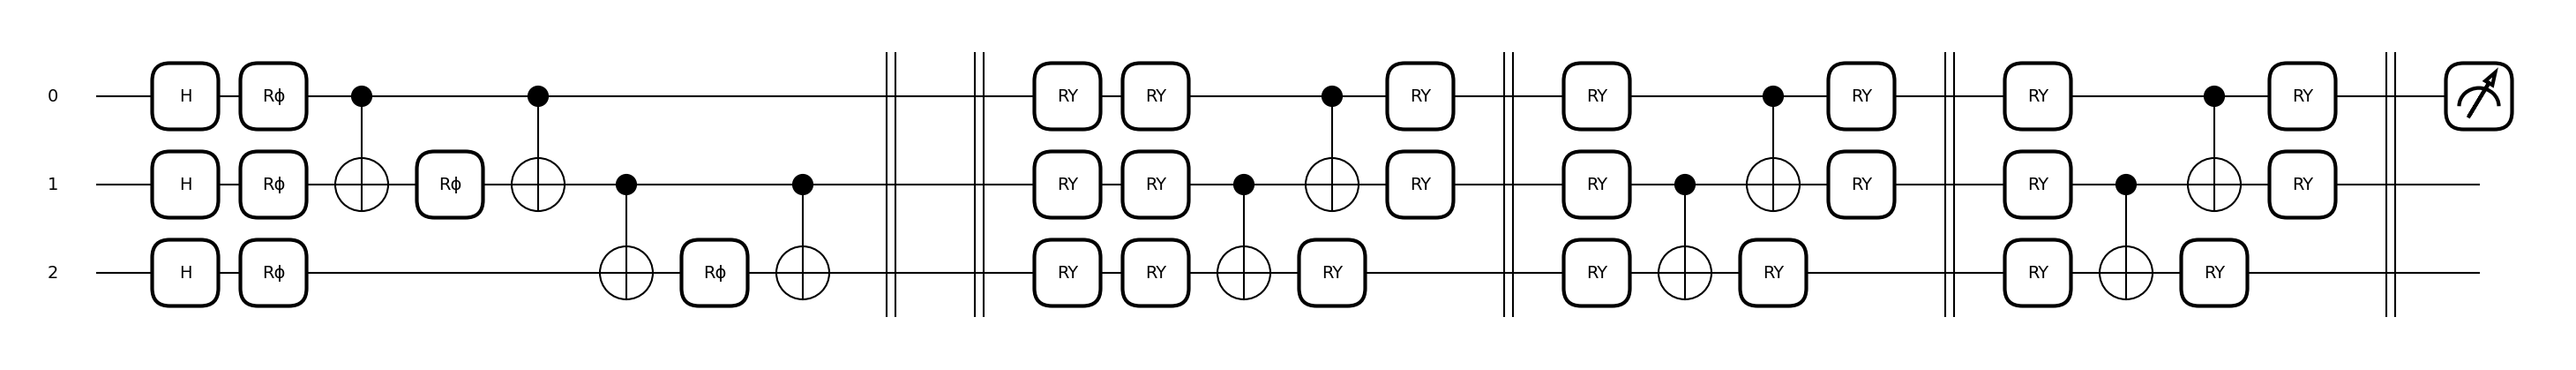

In [21]:
# / ----------------------- \ #
# | FM+Ansatz visualisation | #
# \ ----------------------- / #
qml.drawer.use_style('black_white')  # Optional style

#fig, ax = qml.draw_mpl(qml.transforms.decompose(many_shots_default_qvc_circuit), expansion_strategy="device")(np.append(X_train_sampled[0], [0.0]), init_params)
fig, ax = qml.draw_mpl(qml.transforms.decompose(many_shots_default_qvc_circuit), expansion_strategy="device")(X_train_sampled[0], init_params)
plt.show()

In [23]:
# Try forward pass
many_shots_default_qvc_forward(X_train_sampled[1], init_params)

(tensor([0.61914062, 0.38085938], requires_grad=True), 1024)

In [23]:
# Try loss function
many_shots_default_loss_fn(init_params, X_train_sampled[:1], y_train_sampled[:1])

(tensor([0.72288178], requires_grad=True), tensor([1024], requires_grad=True))

In [22]:
# Train QNN - One shot, Hamming distance, Unambiqous model
params = init_params.copy()
#params = trained_weights
# n_qubits = 5
#epochs = 300
#opt_config = {"maxiter": epochs, "a": 0.4,}

# n_qubits = 3
epochs = 300
batch_size = 8
#opt_config = {"maxiter": epochs, "a": 0.2,} 
opt = qml.AdamOptimizer(stepsize=0.1,)                           # 47 sec per epoch, 2 layers, data C, 3 qubits

trained_weights, history_per_batch, history_per_epoch = many_shots_default_train_qnn(X_train_sampled, y_train_sampled, opt=opt, loss_fn=many_shots_default_loss_fn, params=params, epochs=epochs, batch_size=batch_size)

Epoch 1
	Avg train Loss            : 0.6117
	Min/Avg/Max train # of executions : 1024/1024.0000/1024
	Train Accuracy	: 0.6531
	Train Precision	: 0.5000
	Train Recall	: 0.3662
	Train F1	: 0.4228
	Train ROC AUC	: 0.6984
	Train Min number of executions	: 1024.0000
	Train Avg number of executions	: 1024.0000
	Train Max number of executions	: 1024.0000
	Train Classification time[s]	: 3.5782
	Train Min time per forward pass[s]	: 0.0030
	Train Avg time per forward pass[s]	: 0.0056
	Train Max time per forward pass[s]	: 0.0159
Epoch 2
	Avg train Loss            : 0.5995
	Min/Avg/Max train # of executions : 1024/1024.0000/1024
	Train Accuracy	: 0.6954
	Train Precision	: 0.6354
	Train Recall	: 0.2864
	Train F1	: 0.3948
	Train ROC AUC	: 0.7677
	Train Min number of executions	: 1024.0000
	Train Avg number of executions	: 1024.0000
	Train Max number of executions	: 1024.0000
	Train Classification time[s]	: 8.2287
	Train Min time per forward pass[s]	: 0.0035
	Train Avg time per forward pass[s]	: 0.01

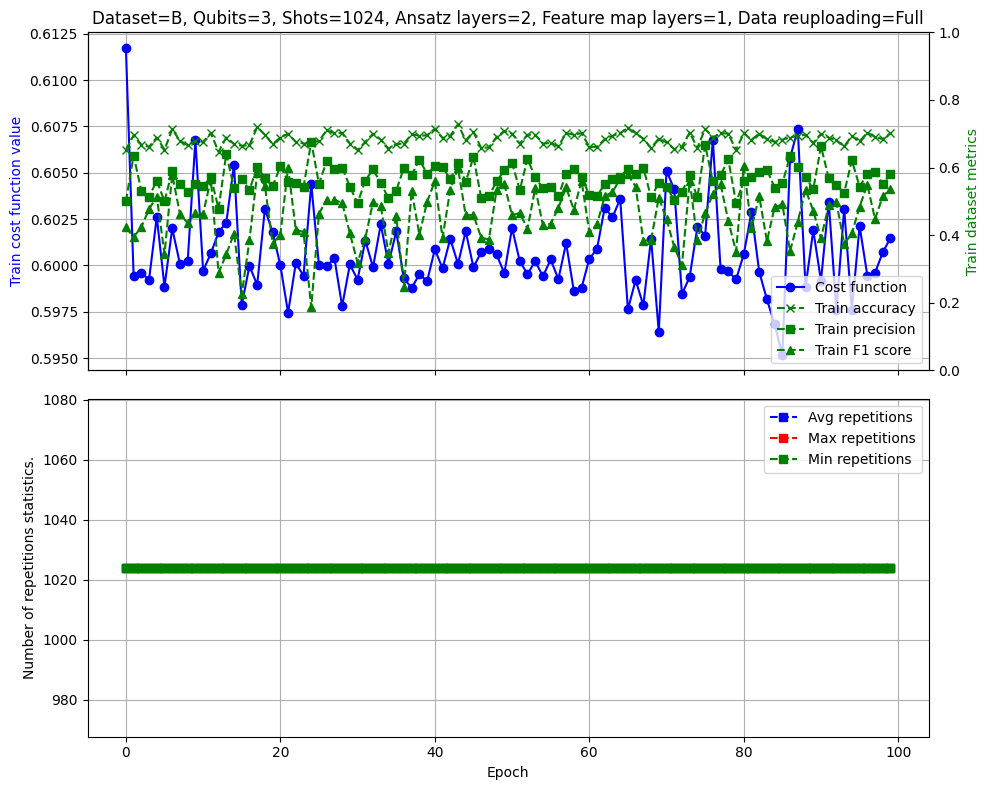

In [23]:
plot_history(history_per_epoch, output_file=training_history_plot_file, ansatz_layers=n_reps_ansatz, fm_layers=n_reps_fm, n_shots=n_shots, n_qubits=n_qubits, dataset=dataset, data_reuploading=data_reupload)

In [32]:
# Run the model on test data
get_metrics(X_test_sampled, y_test_sampled, trained_weights, forward_func=many_shots_default_qvc_forward, show = True)

Accuracy                         : 0.8158
Precision                        : 0.7907
Recall                           : 0.9577
F1 Score                         : 0.8662
ROC AUC                          : 0.9415
Min/Avg/Max # of executions      : 1024/1024.0000/1024
Classification time elapsed      : 0.1361207009977079s 
Min/Avg/Max forward time elapsed : 0/0/0


{'Accuracy': 0.8157894736842105,
 'Precision': 0.7906976744186046,
 'Recall': 0.9577464788732394,
 'F1': 0.8662420382165605,
 'ROC AUC': np.float64(0.9415329184408779),
 'Min number of executions': np.int64(1024),
 'Avg number of executions': np.float64(1024.0),
 'Max number of executions': np.int64(1024),
 'Classification time[s]': 0.1361207009977079,
 'Min time per forward pass[s]': 0,
 'Avg time per forward pass[s]': 0,
 'Max time per forward pass[s]': 0}

## QVC - many shots, Humming distance

In [44]:
# / -------------------------- \ #
# | QNN definition, Pennylane  | #
# \ -------------------------- / #

# Initialize hyperparameters specific to this model
n_shots = 1024
max_executions = n_shots

# Set up the quantum device
dev = qml.device("lightning.qubit", wires=n_qubits, shots=n_shots)
            
# Combine into a full PQC
@qml.qnode(dev)
def many_shots_hamming_qvc_circuit(x, weights):
    zz_feature_map(x)
    qml.Barrier()
    ansatz(weights, x)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    #return qml.sample(wires=range(n_qubits))  # samples in Z-basis on every qubit

In [22]:
# Try to run simulation on one data point
res = np.array(many_shots_hamming_qvc_circuit(X_train_sampled[:1], init_params)).T

print(f"Dimension of output: {res.shape}\n")
print(f"Output:\n{res}")

Dimension of output: (1, 5)

Output:
[[-0.10351562  0.0546875  -0.36328125  0.08203125  0.69726562]]


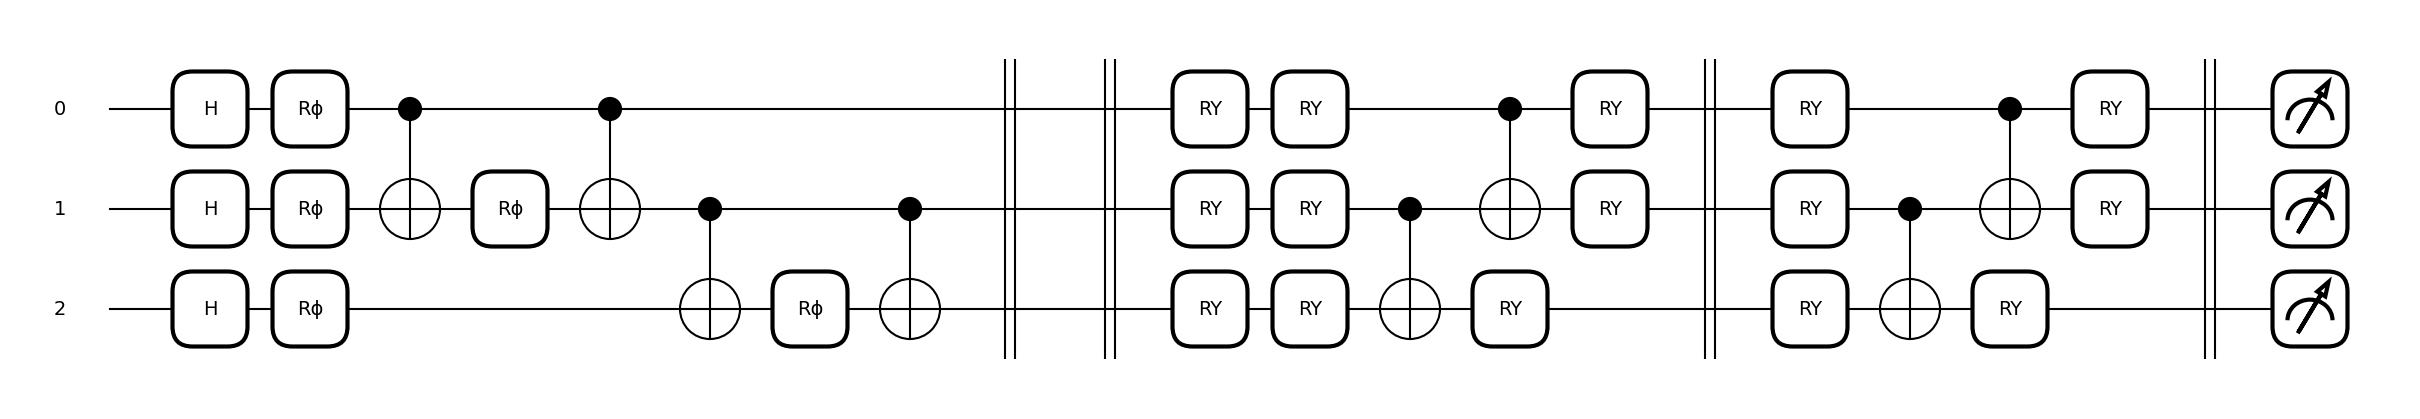

In [31]:
# / ----------------------- \ #
# | FM+Ansatz visualisation | #
# \ ----------------------- / #
qml.drawer.use_style('black_white')  # Optional style

#fig, ax = qml.draw_mpl(qml.transforms.decompose(many_shots_hamming_qvc_circuit), expansion_strategy="device")(np.append(X_train_sampled[0], [0.0]), init_params)
fig, ax = qml.draw_mpl(qml.transforms.decompose(many_shots_hamming_qvc_circuit), expansion_strategy="device")(X_train_sampled[0], init_params)
plt.show()

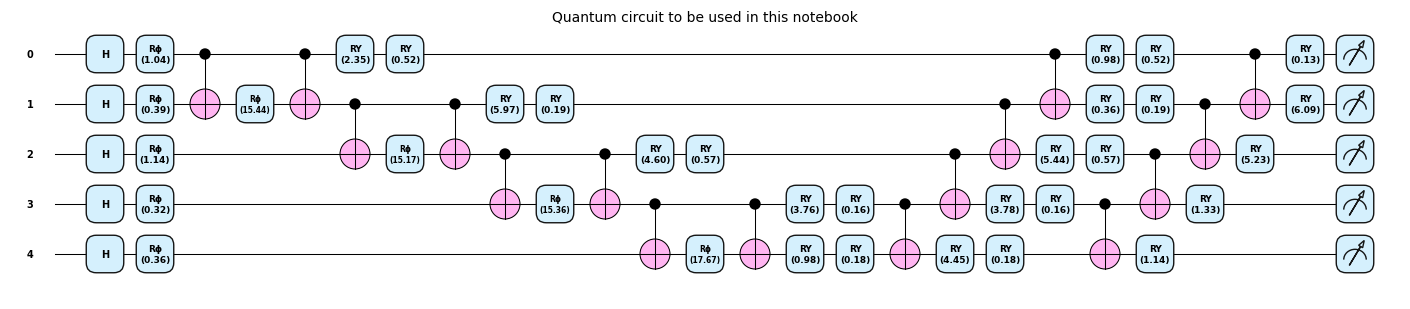

In [24]:
# / ----------------------- \ #
# | FM+Ansatz visualisation | #
# \ ----------------------- / #
draw_circuit(many_shots_hamming_qvc_circuit, scale=0.5, title='Quantum circuit to be used in this notebook', level='device')(X_train_sampled[0], init_params) # level='device'/'gradient'

In [25]:
# Try forward pass
many_shots_hamming_qvc_forward(X_train_sampled[:1], init_params)

(tensor([0.57421875], requires_grad=True), tensor([1024], requires_grad=True))

In [26]:
# Try loss function
many_shots_hamming_loss_fn(init_params, X_train_sampled[:1], y_train_sampled[:1])

(tensor([0.45878892], requires_grad=True), tensor([1024], requires_grad=True))

In [45]:
# Train QNN - One shot, Hamming distance, Unambiqous model
params = init_params.copy()
#params = trained_weights
# n_qubits = 3
epochs = 300
batch_size = 8

opt = qml.optimize.SPSAOptimizer(maxiter=epochs, a=None,)
# opt = qml.AdagradOptimizer(stepsize=0.05,)                         # 9 sec per epoch, 2 layers, data A, 3 qubits
# opt = qml.AdagradOptimizer(stepsize=0.05,)                       # 72 sec per epoch, 2 layers, data B, 5 qubits
# opt = qml.AdagradOptimizer(stepsize=0.01,)                       # 25 sec per epoch, 2 layers, data B, 3 qubits
# opt = qml.AdamOptimizer(stepsize=0.05,)                          # 47 sec per epoch, 2 layers, data C, 5 qubits
# opt = qml.AdamOptimizer(stepsize=0.1,)                           # 47 sec per epoch, 2 layers, data C, 3 qubits
# opt = qml.GradientDescentOptimizer(stepsize=0.5)
## opt = qml.NesterovMomentumOptimizer(stepsize=0.5)
# opt = RCDOptimizer(h=0.1)
#opt = qml.RMSPropOptimizer(stepsize=0.1, decay=0.7, eps=1e-08)  # 50 sec per epoch, 2 layers, data C, 5 qubits


trained_weights, history_per_batch, history_per_epoch = many_shots_hamming_train_qnn(X_train_sampled, y_train_sampled, opt=opt, loss_fn=many_shots_hamming_loss_fn, params=params, epochs=epochs, batch_size=batch_size)

Epoch 1
	Avg train Loss            : 0.9054
	Min/Avg/Max train # of executions : 1024/1024.0000/1024
	Train Accuracy	: 0.3934
	Train Precision	: 0.5568
	Train Recall	: 0.1713
	Train F1	: 0.2620
	Train ROC AUC	: 0.3422
	Train Min number of executions	: 1024.0000
	Train Avg number of executions	: 1024.0000
	Train Max number of executions	: 1024.0000
	Train Classification time[s]	: 1.8199
	Train Min time per forward pass[s]	: 0.0035
	Train Avg time per forward pass[s]	: 0.0040
	Train Max time per forward pass[s]	: 0.0081
Epoch 2
	Avg train Loss            : 0.7837
	Min/Avg/Max train # of executions : 1024/1024.0000/1024
	Train Accuracy	: 0.4022
	Train Precision	: 0.5372
	Train Recall	: 0.3531
	Train F1	: 0.4262
	Train ROC AUC	: 0.3745
	Train Min number of executions	: 1024.0000
	Train Avg number of executions	: 1024.0000
	Train Max number of executions	: 1024.0000
	Train Classification time[s]	: 1.9026
	Train Min time per forward pass[s]	: 0.0036
	Train Avg time per forward pass[s]	: 0.00

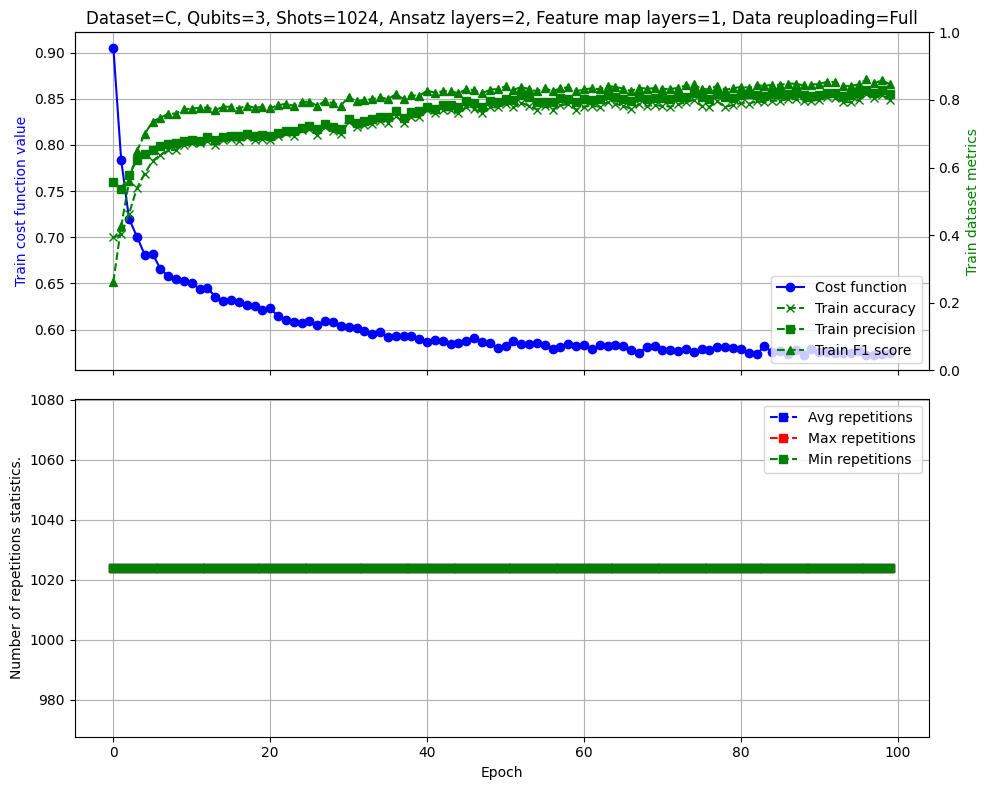

In [48]:
plot_history(history_per_epoch, output_file=training_history_plot_file, ansatz_layers=n_reps_ansatz, fm_layers=n_reps_fm, n_shots=n_shots, n_qubits=n_qubits, dataset=dataset, data_reuploading=data_reupload)

In [209]:
# Run the model on test data
get_metrics(X_test_sampled, y_test_sampled, trained_weights, forward_func=many_shots_hamming_qvc_forward, show = True)

Accuracy                         : 0.8246
Precision                        : 0.7865
Recall                           : 0.9859
F1 Score                         : 0.8750
ROC AUC                          : 0.9840
Min/Avg/Max # of executions      : 1024/1024.0000/1024
Classification time elapsed      : 0.2342931729999691s 
Min/Avg/Max forward time elapsed : 0/0/0


{'Accuracy': 0.8245614035087719,
 'Precision': 0.7865168539325843,
 'Recall': 0.9859154929577465,
 'F1': 0.875,
 'ROC AUC': 0.983950212905339,
 'Min number of executions': 1024,
 'Avg number of executions': 1024,
 'Max number of executions': 1024,
 'Classification time[s]': 0.2342931729999691,
 'Min time per forward pass[s]': 0,
 'Avg time per forward pass[s]': 0,
 'Max time per forward pass[s]': 0}

## QVC - one shot, Humming distance + Unambiqous

In [29]:
# / -------------------------- \ #
# | QNN definition, Pennylane  | #
# \ -------------------------- / #

# Initialize hyperparameters specific to this model
n_shots = 1
max_executions = 50
#classify_threshold = n_qubits # defined as count of qubits, which needs to be measured and have same value to the number of all qubits.
classify_threshold = n_qubits # defined as absolute threshold for sum of exp values in range [0, n_qubits] 

# Set up the quantum device
dev = qml.device("lightning.qubit", wires=n_qubits, shots=n_shots)
      
# Combine into a full PQC
@qml.qnode(dev)
def one_shot_hamming_unambiqous_qvc_circuit(x, weights):
    zz_feature_map(x)
    qml.Barrier()
    ansatz(weights, x)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    #return qml.sample(wires=range(n_qubits))  # samples in Z-basis on every qubit

In [35]:
# Try to run simulation on one data point
res = np.array(one_shot_hamming_unambiqous_qvc_circuit(X_train_sampled[0], init_params))

print(f"Dimension of output: {res.shape}\n")
print(f"Output:\n{res}")

Dimension of output: (2,)

Output:
[0 1]


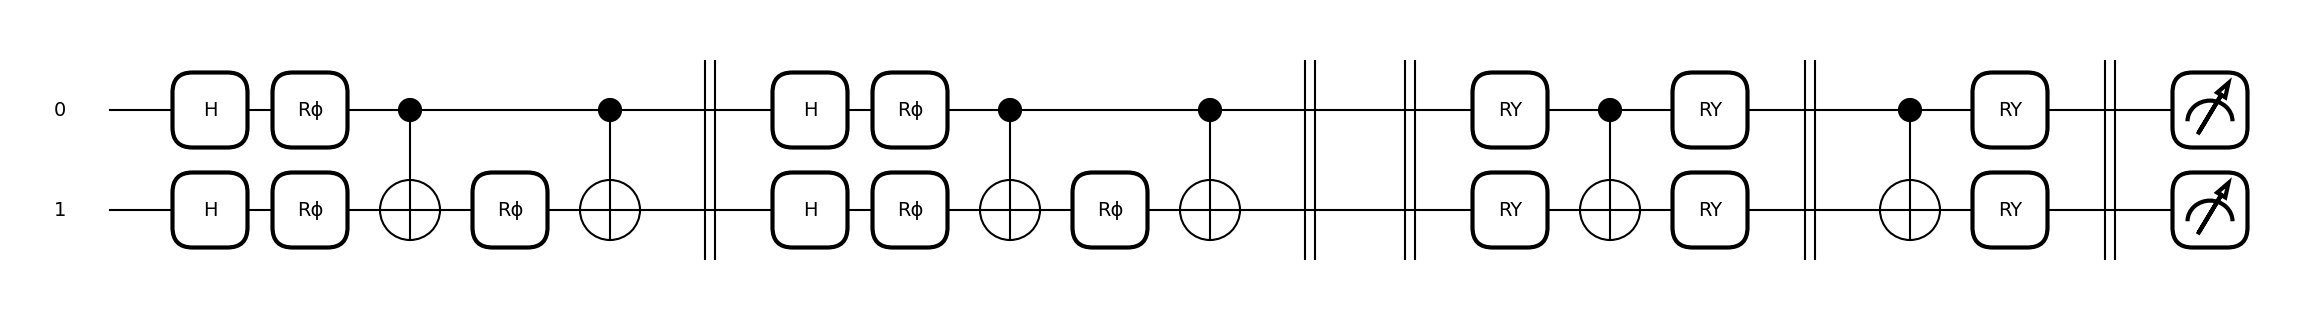

In [36]:
# / ----------------------- \ #
# | FM+Ansatz visualisation | #
# \ ----------------------- / #
qml.drawer.use_style('black_white')  # Optional style

#fig, ax = qml.draw_mpl(qml.transforms.decompose(one_shot_hamming_unambiqous_qvc_circuit), expansion_strategy="device")(np.append(X_train_sampled[0], [0.0]), init_params)
fig, ax = qml.draw_mpl(qml.transforms.decompose(one_shot_hamming_unambiqous_qvc_circuit), expansion_strategy="device")(X_train_sampled[0], init_params)
plt.show()

In [42]:
# Try forward pass
one_shot_hamming_unambiqous_qvc_forward(X_train_sampled[0], init_params)

(tensor([0., 1.], requires_grad=True), 1)

In [43]:
# Try loss function    
one_shot_hamming_unambiqous_loss_fn(init_params, X_train_sampled[0], y_train_sampled[0])

(tensor(-1.00000008e-10, requires_grad=True), 6)

In [30]:
# Train QNN - One shot, Hamming distance, Unambiqous model
params = init_params.copy()
opt = qml.optimize.SPSAOptimizer(maxiter=300, a=None,)

trained_weights, history_per_batch, history_per_epoch = one_shot_hamming_unambiqous_train_qnn(X_train_sampled, y_train_sampled, loss_fn=one_shot_hamming_unambiqous_loss_fn, params=params, epochs=300, batch_size=8, opt=opt)

Epoch 1
	Avg train Loss            : 0.9047
	Min/Avg/Max train # of executions : 1/2.3333/50
	Train Accuracy	: 0.4615
	Train Precision	: 0.7158
	Train Recall	: 0.2378
	Train F1	: 0.3570
	Train ROC AUC	: 0.5390
	Train Min number of executions	: 1.0000
	Train Avg number of executions	: 2.1912
	Train Max number of executions	: 30.0000
	Train Classification time[s]	: 4.5804
	Train Min time per forward pass[s]	: 0.0035
	Train Avg time per forward pass[s]	: 0.0101
	Train Max time per forward pass[s]	: 0.1263
Epoch 2
	Avg train Loss            : 0.8784
	Min/Avg/Max train # of executions : 1/2.4436/24
	Train Accuracy	: 0.4505
	Train Precision	: 0.7308
	Train Recall	: 0.1993
	Train F1	: 0.3132
	Train ROC AUC	: 0.5375
	Train Min number of executions	: 1.0000
	Train Avg number of executions	: 2.5802
	Train Max number of executions	: 30.0000
	Train Classification time[s]	: 5.3231
	Train Min time per forward pass[s]	: 0.0035
	Train Avg time per forward pass[s]	: 0.0117
	Train Max time per forward p

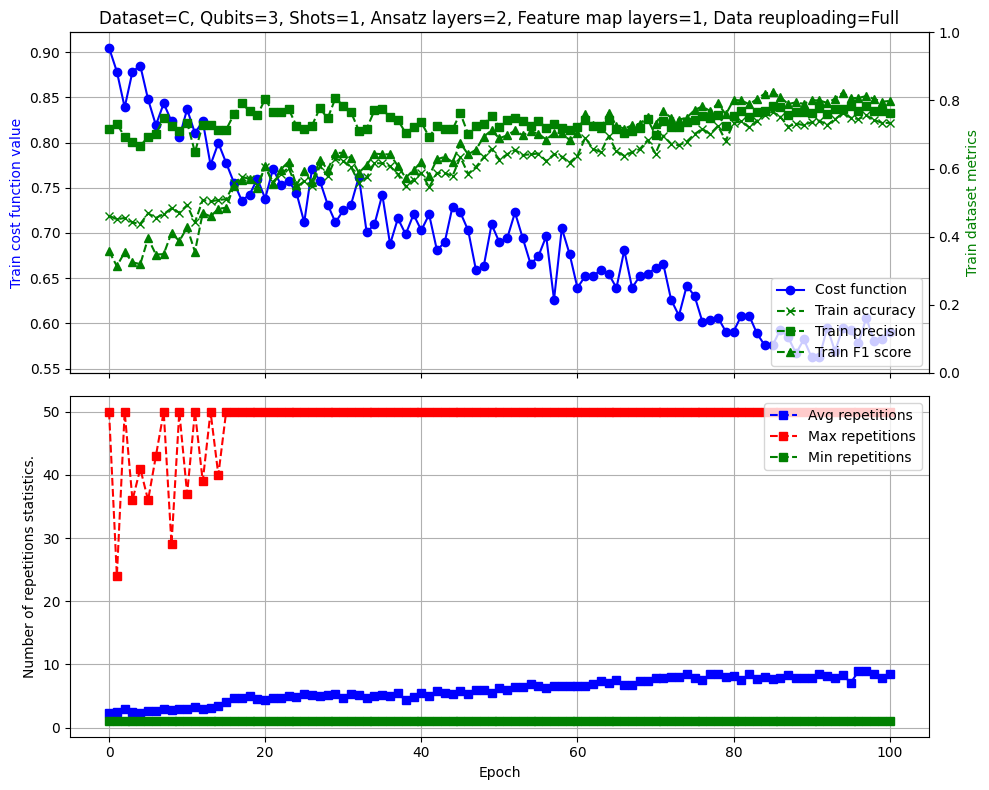

In [31]:
plot_history(history_per_epoch, output_file={training_history_plot_file}, ansatz_layers=n_reps_ansatz, fm_layers=n_reps_fm, n_shots=n_shots, n_qubits=n_qubits, dataset=dataset, data_reuploading=data_reupload)

In [109]:
# Run the model on test data
get_metrics(X_test_sampled, y_test_sampled, trained_weights, one_shot_hamming_unambiqous_qvc_forward, show = True)

Accuracy                    : 0.7895
Precision                   : 0.8310
Recall                      : 0.8310
F1 Score                    : 0.8310
ROC AUC                     : 0.7760
Min/Avg/Max # of executions : 1/2.6140/32


{'Accuracy': 0.7894736842105263,
 'Precision': 0.8309859154929577,
 'Recall': 0.8309859154929577,
 'F1': 0.8309859154929577,
 'ROC AUC': np.float64(0.7759580740255486)}

# Comparison

In [24]:
# save/load training history
mode = "save" # "save", "overwrite", "load"

if mode == "save":
    if os.path.exists(f"./results/{training_history_file}"):
        print(f"⚠️ Warning: ./results/{training_history_file} already exists!")
    else:
        with open(f"./results/{training_history_file}", "w") as f:
            history_per_epoch["train_loss"]["avg"] = [float(x) for x in history_per_epoch["train_loss"]["avg"]]
            history_per_epoch["train_exec"]["min"] = [int(x) for x in history_per_epoch["train_exec"]["min"]]
            history_per_epoch["train_exec"]["max"] = [int(x) for x in history_per_epoch["train_exec"]["max"]]         
            history_per_epoch["train_exec"]["avg"] = [float(x) for x in history_per_epoch["train_exec"]["avg"]]     
            history_per_epoch["train_avg_scores"]["Accuracy"] = [float(x) for x in history_per_epoch["train_avg_scores"]["Accuracy"]]
            history_per_epoch["train_avg_scores"]["Precision"] = [float(x) for x in history_per_epoch["train_avg_scores"]["Precision"]]
            history_per_epoch["train_avg_scores"]["Recall"] = [float(x) for x in history_per_epoch["train_avg_scores"]["Recall"]]
            history_per_epoch["train_avg_scores"]["F1"] = [float(x) for x in history_per_epoch["train_avg_scores"]["F1"]]
            history_per_epoch["train_avg_scores"]["ROC AUC"] = [float(x) for x in history_per_epoch["train_avg_scores"]["ROC AUC"]]
            history_per_epoch["train_avg_scores"]["Min number of executions"] = [int(x) for x in history_per_epoch["train_avg_scores"]["Min number of executions"]]
            history_per_epoch["train_avg_scores"]["Avg number of executions"] = [float(x) for x in history_per_epoch["train_avg_scores"]["Avg number of executions"]]
            history_per_epoch["train_avg_scores"]["Max number of executions"] = [int(x) for x in history_per_epoch["train_avg_scores"]["Max number of executions"]]
            history_per_epoch["train_avg_scores"]["Classification time[s]"] = [float(x) for x in history_per_epoch["train_avg_scores"]["Classification time[s]"]]
            history_per_epoch["train_avg_scores"]["Min time per forward pass[s]"] = [float(x) for x in history_per_epoch["train_avg_scores"]["Min time per forward pass[s]"]]
            history_per_epoch["train_avg_scores"]["Avg time per forward pass[s]"] = [float(x) for x in history_per_epoch["train_avg_scores"]["Avg time per forward pass[s]"]]
            history_per_epoch["train_avg_scores"]["Max time per forward pass[s]"] = [float(x) for x in history_per_epoch["train_avg_scores"]["Max time per forward pass[s]"]]

            json.dump(history_per_epoch, f, indent=4)
elif mode == "overwrite":
    with open(f"./results/{training_history_file}", "w") as f:
        history_per_epoch["train_loss"]["avg"] = [float(x) for x in history_per_epoch["train_loss"]["avg"]]
        history_per_epoch["train_exec"]["min"] = [int(x) for x in history_per_epoch["train_exec"]["min"]]
        history_per_epoch["train_exec"]["max"] = [int(x) for x in history_per_epoch["train_exec"]["max"]]
        history_per_epoch["train_exec"]["avg"] = [float(x) for x in history_per_epoch["train_exec"]["avg"]]
        json.dump(history_per_epoch, f, indent=4)
elif mode == "load":
    with open(f"./results/{training_history_file}", "r") as f:
        loaded_history_per_epoch = json.load(f)

In [25]:
# save/load trained weights 
mode = "save" # "save", "overwrite", "load"
#weights_file = "w_qubits=3_layersFM=1_layersAnsatz=2_DataReupload=Full_Dataset=C_trained=2.v2.npy"

if mode == "save":
    if os.path.exists(f"./weights/{weights_file}"):
        print(f"⚠️ Warning: ./weights/{weights_file} already exists!")
    else:
        np.save(f"./weights/{weights_file}", trained_weights)
elif mode == "overwrite":
    np.save(f"./weights/{weights_file}", trained_weights)
elif mode == "load":
    # Load trained weights
    loaded_weights = np.load(f"./weights/{weights_file}", allow_pickle=True)
    loaded_weights = np.array(loaded_weights, requires_grad=True)
    print(loaded_weights)

In [26]:
# define number of classification runs for each experiment
n_classification_iterations = 25
add_noise_qnode = functools.partial(add_noise, p_depol=0.02, p_amp=0.05, p_phase=0.03) # define noise model

In [27]:
loaded_weights = trained_weights

## Experiment 1

### Noiseless

In [28]:
# Experiment 1, many shots, one qubit decision
n_shots = 1024
max_executions = n_shots
#dev = qml.device("qiskit.aer", backend_name="aer_simulator", wires=n_qubits, shots=n_shots, noise_model=None)
dev = qml.device("default.mixed", wires=n_qubits, shots=n_shots )
# Combine into a full PQC
@qml.qnode(dev)
def many_shots_default_qvc_circuit(x, weights):
    zz_feature_map(x)
    qml.Barrier()
    ansatz(weights, x)
    return [qml.expval(qml.PauliZ(0))]
    #return qml.sample(wires=[0])  # samples in Z-basis on single qubit
    
temp = []
# run classification N times to have a statistics
for i in range(1, n_classification_iterations+1):
    print(f"Classification iteration: {i}/{n_classification_iterations}")
    metrics = get_metrics(X_test_sampled, y_test_sampled, loaded_weights, many_shots_default_qvc_forward, show = False)
    # append aditional data to metrics
    data = {"iteration": i, "dataset": dataset, "model": "X", "noise_model": "None"}
    data.update(metrics)
    temp.append(data)

df_exp1_noiseless = pd.DataFrame(temp)
del temp
df_exp1_noiseless.head()

Classification iteration: 1/25
Classification iteration: 2/25
Classification iteration: 3/25
Classification iteration: 4/25
Classification iteration: 5/25
Classification iteration: 6/25
Classification iteration: 7/25
Classification iteration: 8/25
Classification iteration: 9/25
Classification iteration: 10/25
Classification iteration: 11/25
Classification iteration: 12/25
Classification iteration: 13/25
Classification iteration: 14/25
Classification iteration: 15/25
Classification iteration: 16/25
Classification iteration: 17/25
Classification iteration: 18/25
Classification iteration: 19/25
Classification iteration: 20/25
Classification iteration: 21/25
Classification iteration: 22/25
Classification iteration: 23/25
Classification iteration: 24/25
Classification iteration: 25/25


,iteration,dataset,model,noise_model,Accuracy,Precision,Recall,F1,ROC AUC,Min number of executions,Avg number of executions,Max number of executions,Classification time[s],Min time per forward pass[s],Avg time per forward pass[s],Max time per forward pass[s]
0,1,B,X,None,0.642857,0.500000,0.345455,0.408602,0.699357,1024,1024.0,1024,3.370419,0.019616,0.021600,0.040498
1,2,B,X,None,0.642857,0.500000,0.345455,0.408602,0.696143,1024,1024.0,1024,3.657266,0.019508,0.023437,0.094928
2,3,B,X,None,0.642857,0.500000,0.345455,0.408602,0.697521,1024,1024.0,1024,3.814180,0.019720,0.024448,0.054285
3,4,B,X,None,0.655844,0.526316,0.363636,0.430108,0.707622,1024,1024.0,1024,3.283860,0.019565,0.021047,0.029855
4,5,B,X,None,0.642857,0.500000,0.345455,0.408602,0.698806,1024,1024.0,1024,3.388842,0.019250,0.021722,0.054059


### Noise

In [29]:
# Experiment 1, many shots, one qubit decision
n_shots = 1024
max_executions = n_shots
#dev = qml.device("qiskit.aer", backend_name="aer_simulator", wires=n_qubits, shots=n_shots, noise_model=noise_model)
dev = qml.device("default.mixed", wires=n_qubits, shots=n_shots )

# Combine into a full PQC
@qml.qnode(dev)
@add_noise_qnode
def many_shots_default_qvc_circuit(x, weights):
    zz_feature_map(x)
    qml.Barrier()
    ansatz(weights, x)
    return [qml.expval(qml.PauliZ(0))]
    #return qml.sample(wires=[0])  # samples in Z-basis on single qubit
    
temp = []
# run classification N times to have a statistics
for i in range(1, n_classification_iterations+1):
    print(f"Classification iteration: {i}/{n_classification_iterations}")
    metrics = get_metrics(X_test_sampled, y_test_sampled, loaded_weights, many_shots_default_qvc_forward, show = False)
    # append aditional data to metrics
    data = {"iteration": i, "dataset": dataset, "model": "X", "noise_model": "Basic"}
    data.update(metrics)
    temp.append(data)

df_exp1_noise = pd.DataFrame(temp)
del temp
df_exp1_noise.head()

Classification iteration: 1/25
Classification iteration: 2/25
Classification iteration: 3/25
Classification iteration: 4/25
Classification iteration: 5/25
Classification iteration: 6/25
Classification iteration: 7/25
Classification iteration: 8/25
Classification iteration: 9/25
Classification iteration: 10/25
Classification iteration: 11/25
Classification iteration: 12/25
Classification iteration: 13/25
Classification iteration: 14/25
Classification iteration: 15/25
Classification iteration: 16/25
Classification iteration: 17/25
Classification iteration: 18/25
Classification iteration: 19/25
Classification iteration: 20/25
Classification iteration: 21/25
Classification iteration: 22/25
Classification iteration: 23/25
Classification iteration: 24/25
Classification iteration: 25/25


,iteration,dataset,model,noise_model,Accuracy,Precision,Recall,F1,ROC AUC,Min number of executions,Avg number of executions,Max number of executions,Classification time[s],Min time per forward pass[s],Avg time per forward pass[s],Max time per forward pass[s]
0,1,B,X,Basic,0.558442,0.436893,0.818182,0.569620,0.702571,1024,1024.0,1024,6.236482,0.037095,0.040376,0.147155
1,2,B,X,Basic,0.590909,0.461538,0.872727,0.603774,0.703030,1024,1024.0,1024,6.249002,0.037379,0.040455,0.045077
2,3,B,X,Basic,0.603896,0.471154,0.890909,0.616352,0.719743,1024,1024.0,1024,6.393112,0.037218,0.041393,0.116603
3,4,B,X,Basic,0.571429,0.445545,0.818182,0.576923,0.717355,1024,1024.0,1024,6.283301,0.037599,0.040677,0.046772
4,5,B,X,Basic,0.603896,0.470588,0.872727,0.611465,0.715611,1024,1024.0,1024,6.344405,0.037387,0.041073,0.105351


## Experiment 2

### Noiseless

In [60]:
# Experiment 2, many shots, hamming
n_shots = 1024
max_executions = n_shots
dev = qml.device("default.mixed", wires=n_qubits, shots=n_shots )
# Combine into a full PQC
@qml.qnode(dev)
def many_shots_hamming_qvc_circuit(x, weights):
    zz_feature_map(x)
    qml.Barrier()
    ansatz(weights, x)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    #return qml.sample(wires=range(n_qubits))  # samples in Z-basis on every qubit
    
temp = []
# run classification N times to have a statistics
for i in range(1, n_classification_iterations+1):
    print(f"Classification iteration: {i}/{n_classification_iterations}")
    metrics = get_metrics(X_test_sampled, y_test_sampled, loaded_weights, many_shots_hamming_qvc_forward, show = False)
    # append aditional data to metrics
    data = {"iteration": i, "dataset": dataset, "model": "Y", "noise_model": "None"}
    data.update(metrics)
    temp.append(data)

df_exp2_noiseless = pd.DataFrame(temp)
del temp
df_exp2_noiseless.head()

Classification iteration: 1/25
Classification iteration: 2/25
Classification iteration: 3/25
Classification iteration: 4/25
Classification iteration: 5/25
Classification iteration: 6/25
Classification iteration: 7/25
Classification iteration: 8/25
Classification iteration: 9/25
Classification iteration: 10/25
Classification iteration: 11/25
Classification iteration: 12/25
Classification iteration: 13/25
Classification iteration: 14/25
Classification iteration: 15/25
Classification iteration: 16/25
Classification iteration: 17/25
Classification iteration: 18/25
Classification iteration: 19/25
Classification iteration: 20/25
Classification iteration: 21/25
Classification iteration: 22/25
Classification iteration: 23/25
Classification iteration: 24/25
Classification iteration: 25/25


,iteration,dataset,model,noise_model,Accuracy,Precision,Recall,F1,ROC AUC,Min number of executions,Avg number of executions,Max number of executions,Classification time[s],Min time per forward pass[s],Avg time per forward pass[s],Max time per forward pass[s]
0,1,C,Y,None,0.789474,0.758242,0.971831,0.851852,0.896168,1024,1024.0,1024,3.105025,0.024040,0.027200,0.044752
1,2,C,Y,None,0.780702,0.755556,0.957746,0.844720,0.886014,1024,1024.0,1024,3.107204,0.023297,0.027221,0.068717
2,3,C,Y,None,0.807018,0.775281,0.971831,0.862500,0.887488,1024,1024.0,1024,3.000960,0.023486,0.026287,0.039963
3,4,C,Y,None,0.807018,0.781609,0.957746,0.860759,0.886833,1024,1024.0,1024,3.079851,0.022639,0.026979,0.039110
4,5,C,Y,None,0.780702,0.750000,0.971831,0.846626,0.881592,1024,1024.0,1024,3.022940,0.022176,0.026479,0.033281


### Noise

In [61]:
# Experiment 2, many shots, hamming
n_shots = 1024
max_executions = n_shots
dev = qml.device("default.mixed", wires=n_qubits, shots=n_shots )
# Combine into a full PQC
@qml.qnode(dev)
@add_noise_qnode
def many_shots_hamming_qvc_circuit(x, weights):
    zz_feature_map(x)
    qml.Barrier()
    ansatz(weights, x)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    #return qml.sample(wires=range(n_qubits))  # samples in Z-basis on every qubit
    
temp = []
# run classification N times to have a statistics
for i in range(1, n_classification_iterations+1):
    print(f"Classification iteration: {i}/{n_classification_iterations}")
    metrics = get_metrics(X_test_sampled, y_test_sampled, loaded_weights, many_shots_hamming_qvc_forward, show = False)
    # append aditional data to metrics
    data = {"iteration": i, "dataset": dataset, "model": "Y", "noise_model": "Basic"}
    data.update(metrics)
    temp.append(data)

df_exp2_noise = pd.DataFrame(temp)
del temp
df_exp2_noise.head()

Classification iteration: 1/25
Classification iteration: 2/25
Classification iteration: 3/25
Classification iteration: 4/25
Classification iteration: 5/25
Classification iteration: 6/25
Classification iteration: 7/25
Classification iteration: 8/25
Classification iteration: 9/25
Classification iteration: 10/25
Classification iteration: 11/25
Classification iteration: 12/25
Classification iteration: 13/25
Classification iteration: 14/25
Classification iteration: 15/25
Classification iteration: 16/25
Classification iteration: 17/25
Classification iteration: 18/25
Classification iteration: 19/25
Classification iteration: 20/25
Classification iteration: 21/25
Classification iteration: 22/25
Classification iteration: 23/25
Classification iteration: 24/25
Classification iteration: 25/25


,iteration,dataset,model,noise_model,Accuracy,Precision,Recall,F1,ROC AUC,Min number of executions,Avg number of executions,Max number of executions,Classification time[s],Min time per forward pass[s],Avg time per forward pass[s],Max time per forward pass[s]
0,1,C,Y,Basic,0.675439,0.673469,0.929577,0.781065,0.725843,1024,1024.0,1024,16.654390,0.104988,0.146050,0.262174
1,2,C,Y,Basic,0.719298,0.696970,0.971831,0.811765,0.704880,1024,1024.0,1024,14.246310,0.112711,0.124928,0.219225
2,3,C,Y,Basic,0.710526,0.693878,0.957746,0.804734,0.706027,1024,1024.0,1024,15.933704,0.113838,0.139726,0.494755
3,4,C,Y,Basic,0.684211,0.680412,0.929577,0.785714,0.704717,1024,1024.0,1024,14.283763,0.114845,0.125256,0.156139
4,5,C,Y,Basic,0.710526,0.697917,0.943662,0.802395,0.661972,1024,1024.0,1024,14.422919,0.112298,0.126478,0.185683


## Experiment 3

### Noiseless

In [62]:
# Experiment 3 - one shot, hamming, unambiqous
n_shots = 1
max_executions = 50
classify_threshold = n_qubits # defined as count of qubits, which needs to be measured and have same value to the number of all qubits.
dev = qml.device("default.mixed", wires=n_qubits, shots=n_shots )
# Combine into a full PQC
@qml.qnode(dev)
def one_shot_hamming_unambiqous_qvc_circuit(x, weights):
    zz_feature_map(x)
    qml.Barrier()
    ansatz(weights, x)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    #return qml.sample(wires=range(n_qubits))  # samples in Z-basis on every qubit
    
temp = []
# run classification N times to have a statistics
for i in range(1, n_classification_iterations+1):
    print(f"Classification iteration: {i}/{n_classification_iterations}")
    metrics = get_metrics(X_test_sampled, y_test_sampled, loaded_weights, one_shot_hamming_unambiqous_qvc_forward, show = False)
    # append aditional data to metrics
    data = {"iteration": i, "dataset": dataset, "model": "Z", "noise_model": "None"}
    data.update(metrics)
    temp.append(data)

df_exp3_noiseless = pd.DataFrame(temp)
del temp
df_exp3_noiseless.head()

Classification iteration: 1/25
Classification iteration: 2/25
Classification iteration: 3/25
Classification iteration: 4/25
Classification iteration: 5/25
Classification iteration: 6/25
Classification iteration: 7/25
Classification iteration: 8/25
Classification iteration: 9/25
Classification iteration: 10/25
Classification iteration: 11/25
Classification iteration: 12/25
Classification iteration: 13/25
Classification iteration: 14/25
Classification iteration: 15/25
Classification iteration: 16/25
Classification iteration: 17/25
Classification iteration: 18/25
Classification iteration: 19/25
Classification iteration: 20/25
Classification iteration: 21/25
Classification iteration: 22/25
Classification iteration: 23/25
Classification iteration: 24/25
Classification iteration: 25/25


,iteration,dataset,model,noise_model,Accuracy,Precision,Recall,F1,ROC AUC,Min number of executions,Avg number of executions,Max number of executions,Classification time[s],Min time per forward pass[s],Avg time per forward pass[s],Max time per forward pass[s]
0,1,C,Z,None,0.605263,0.750000,0.549296,0.634146,0.623485,1,15.403509,50,45.739661,0.023438,0.401181,1.417076
1,2,C,Z,None,0.578947,0.725490,0.521127,0.606557,0.597773,1,15.447368,50,29.562494,0.008889,0.259293,1.350106
2,3,C,Z,None,0.543860,0.666667,0.535211,0.593750,0.546675,1,13.728070,50,17.198190,0.008907,0.150844,0.598636
3,4,C,Z,None,0.570175,0.703704,0.535211,0.608000,0.581559,1,15.333333,50,20.534886,0.009438,0.180108,0.634941
4,5,C,Z,None,0.614035,0.736842,0.591549,0.656250,0.621356,1,15.131579,50,20.287628,0.010504,0.177944,0.635231


### Noise

In [63]:
# Experiment 3 - one shot, hamming, unambiqous
n_shots = 1
max_executions = 50
classify_threshold = n_qubits         # defined as count of qubits, which needs to be measured and have same value to the number of all qubits.
dev = qml.device("default.mixed", wires=n_qubits, shots=n_shots )
# Combine into a full PQC
@qml.qnode(dev)
@add_noise_qnode
def one_shot_hamming_unambiqous_qvc_circuit(x, weights):
    zz_feature_map(x)
    qml.Barrier()
    ansatz(weights, x)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    #return qml.sample(wires=range(n_qubits))  # samples in Z-basis on every qubit
    
temp = []
# run classification N times to have a statistics
for i in range(1, n_classification_iterations+1):
    print(f"Classification iteration: {i}/{n_classification_iterations}")
    metrics = get_metrics(X_test_sampled, y_test_sampled, loaded_weights, one_shot_hamming_unambiqous_qvc_forward, show = False)
    # append aditional data to metrics
    data = {"iteration": i, "dataset": dataset, "model": "Z", "noise_model": "Basic"}
    data.update(metrics)
    temp.append(data)

df_exp3_noise = pd.DataFrame(temp)
del temp
df_exp3_noise.head()

Classification iteration: 1/25
Classification iteration: 2/25
Classification iteration: 3/25
Classification iteration: 4/25
Classification iteration: 5/25
Classification iteration: 6/25
Classification iteration: 7/25
Classification iteration: 8/25
Classification iteration: 9/25
Classification iteration: 10/25
Classification iteration: 11/25
Classification iteration: 12/25
Classification iteration: 13/25
Classification iteration: 14/25
Classification iteration: 15/25
Classification iteration: 16/25
Classification iteration: 17/25
Classification iteration: 18/25
Classification iteration: 19/25
Classification iteration: 20/25
Classification iteration: 21/25
Classification iteration: 22/25
Classification iteration: 23/25
Classification iteration: 24/25
Classification iteration: 25/25


,iteration,dataset,model,noise_model,Accuracy,Precision,Recall,F1,ROC AUC,Min number of executions,Avg number of executions,Max number of executions,Classification time[s],Min time per forward pass[s],Avg time per forward pass[s],Max time per forward pass[s]
0,1,C,Z,Basic,0.535088,0.645161,0.563380,0.601504,0.525876,1,5.070175,26,34.477138,0.053948,0.302409,1.529978
1,2,C,Z,Basic,0.482456,0.583333,0.591549,0.587413,0.446937,1,5.570175,25,38.146549,0.054447,0.334596,1.452320
2,3,C,Z,Basic,0.403509,0.525424,0.436620,0.476923,0.392728,1,5.438596,37,37.328875,0.057719,0.327425,2.150859
3,4,C,Z,Basic,0.473684,0.590164,0.507042,0.545455,0.462823,1,4.754386,20,32.269669,0.053785,0.283046,1.184176
4,5,C,Z,Basic,0.552632,0.656250,0.591549,0.622222,0.539961,1,4.991228,25,35.244693,0.054635,0.309142,1.641176


## Result analysis

In [55]:
# merge all results
kind = "all" # all, noise-only, noiseless-only
save_plot = True

if kind == "all":
    df_experiments = pd.concat([df_exp1_noiseless, df_exp1_noise,
                                df_exp2_noiseless, df_exp2_noise,
                                df_exp3_noiseless, df_exp3_noise], ignore_index=True)
elif kind == "noiseless-only":
    df_experiments = pd.concat([df_exp1_noiseless,
                                df_exp2_noiseless,
                                df_exp3_noiseless,], ignore_index=True)
elif kind == "noise-only": 
    df_experiments = pd.concat([df_exp1_noise,
                                df_exp2_noise,
                                df_exp3_noise], ignore_index=True)

In [92]:
# df_experiments = pd.read_csv("results/r_qubits=5_layersFM=1_layersAnsatz=2_DataReupload=Full_Dataset=C_trained=2.v2.csv")

In [93]:
# df_experiments.shape, df_experiments.columns, df_experiments.model.unique()

((150, 16),
 Index(['iteration', 'dataset', 'model', 'noise_model', 'Accuracy', 'Precision',
        'Recall', 'F1', 'ROC AUC', 'Min number of executions',
        'Avg number of executions', 'Max number of executions',
        'Classification time[s]', 'Min time per forward pass[s]',
        'Avg time per forward pass[s]', 'Max time per forward pass[s]'],
       dtype='object'),
 array(['X', 'Y', 'Z'], dtype=object))

In [94]:
# df_experiments = df_experiments.loc[df_experiments.model != "X"]

In [95]:
# Load the saved part results
# df_exp1_noiseless = pd.read_csv(f"./results/r_qubits=5_layersFM=1_layersAnsatz=2_DataReupload=Full_Dataset=C_trained=1.v2.csv_1_a")
# df_exp1_noise     = pd.read_csv(f"./results/r_qubits=5_layersFM=1_layersAnsatz=2_DataReupload=Full_Dataset=C_trained=1.v2.csv_1_b")


In [96]:
# df_experiments = pd.concat([df_exp1_noiseless, df_exp1_noise, df_experiments], ignore_index=True)

In [97]:
# df_experiments["noise_model"] = df_experiments["noise_model"].fillna("None")
# df_experiments[["Precision","Recall", "F1"]] = df_experiments[["Precision","Recall", "F1"]].replace(0, None)

In [30]:
# save/load part results
# df_exp1_noiseless.to_csv(f"./results/{results_file}_1_a", index=False)  # index=False avoids saving the row numbers
# df_exp1_noise.to_csv(f"./results/{results_file}_1_b", index=False)  # index=False avoids saving the row numbers
# df_exp2_noiseless.to_csv(f"./results/{results_file}_2_a", index=False)  # index=False avoids saving the row numbers
# df_exp2_noise.to_csv(f"./results/{results_file}_2_b", index=False)  # index=False avoids saving the row numbers
# df_exp3_noiseless.to_csv(f"./results/{results_file}_3_a", index=False)  # index=False avoids saving the row numbers
# #df_exp3_noise.to_csv(f"./results/{results_file}_3_b", index=False)  # index=False avoids saving the row numbers

In [57]:
# Load the saved part results
# df_exp1_noiseless = pd.read_csv(f"./results/{results_file}_1_a")
# df_exp1_noise     = pd.read_csv(f"./results/{results_file}_1_b")
# df_exp2_noiseless = pd.read_csv(f"./results/{results_file}_2_a")
# df_exp2_noise     = pd.read_csv(f"./results/{results_file}_2_b")
# df_exp3_noiseless = pd.read_csv(f"./results/{results_file}_3_a")
# # df_exp3_noise     = pd.read_csv(f"./results/{results_file}_3_b")  # if you later save it

In [114]:
# save/load all results
mode = "load" # "save", "overwrite", "load"
#results_file = "r_qubits=5_layersFM=1_layersAnsatz=2_DataReupload=Full_Dataset=A_trained=2.v2.csv"

if mode == "save":
    if os.path.exists(f"./results/{results_file}"):
        print(f"⚠️ Warning: ./results/{results_file} already exists!")
    else:
        df_experiments.to_csv(f"./results/{results_file}", index=False)  # index=False avoids saving the row numbers
elif mode == "overwrite":
    df_experiments.to_csv(f"./results/{results_file}", index=False)  # index=False avoids saving the row numbers
elif mode == "load":
    loaded_df_experiments = pd.read_csv(f"./results/{results_file}")
    loaded_df_experiments["noise_model"] = df_experiments["noise_model"].fillna("None")
    loaded_df_experiments[["Precision","Recall", "F1"]] = df_experiments[["Precision","Recall", "F1"]].replace(0, None)

In [59]:
df_experiments.shape

(150, 16)

In [60]:
df_experiments.columns

Index(['iteration', 'dataset', 'model', 'noise_model', 'Accuracy', 'Precision',
       'Recall', 'F1', 'ROC AUC', 'Min number of executions',
       'Avg number of executions', 'Max number of executions',
       'Classification time[s]', 'Min time per forward pass[s]',
       'Avg time per forward pass[s]', 'Max time per forward pass[s]'],
      dtype='object')

In [75]:
df_experiments.head()

,iteration,dataset,model,noise_model,Accuracy,Precision,Recall,F1,ROC AUC,Min number of executions,Avg number of executions,Max number of executions,Classification time[s],Min time per forward pass[s],Avg time per forward pass[s],Max time per forward pass[s]
0,1,A,X,None,0.633333,0.615385,0.32,0.421053,0.660000,1024,1024.0,1024,1.356291,0.020372,0.022465,0.042722
1,2,A,X,None,0.650000,0.666667,0.32,0.432432,0.676000,1024,1024.0,1024,1.830138,0.020702,0.030325,0.106845
2,3,A,X,None,0.650000,0.666667,0.32,0.432432,0.674286,1024,1024.0,1024,1.401334,0.020698,0.023205,0.031740
3,4,A,X,None,0.666667,0.727273,0.32,0.444444,0.674857,1024,1024.0,1024,1.339675,0.020376,0.022193,0.030811
4,5,A,X,None,0.633333,0.615385,0.32,0.421053,0.665143,1024,1024.0,1024,1.342561,0.020646,0.022251,0.028064


In [62]:
df_experiments.loc[(df_experiments["noise_model"]=="Basic") & (df_experiments["model"] == "Y")].head()

,iteration,dataset,model,noise_model,Accuracy,Precision,Recall,F1,ROC AUC,Min number of executions,Avg number of executions,Max number of executions,Classification time[s],Min time per forward pass[s],Avg time per forward pass[s],Max time per forward pass[s]
75,1,A,Y,Basic,0.416667,0.416667,1.0,0.588235,0.576000,1024,1024.0,1024,7.474075,0.105152,0.124550,0.176609
76,2,A,Y,Basic,0.433333,0.423729,1.0,0.595238,0.651429,1024,1024.0,1024,7.081432,0.101265,0.118006,0.232276
77,3,A,Y,Basic,0.416667,0.416667,1.0,0.588235,0.600000,1024,1024.0,1024,6.916029,0.100998,0.115250,0.192260
78,4,A,Y,Basic,0.416667,0.416667,1.0,0.588235,0.695429,1024,1024.0,1024,7.021374,0.104280,0.117005,0.145202
79,5,A,Y,Basic,0.416667,0.416667,1.0,0.588235,0.640000,1024,1024.0,1024,6.680456,0.100698,0.111325,0.220878


### PLOTS

In [43]:
save_plot = True

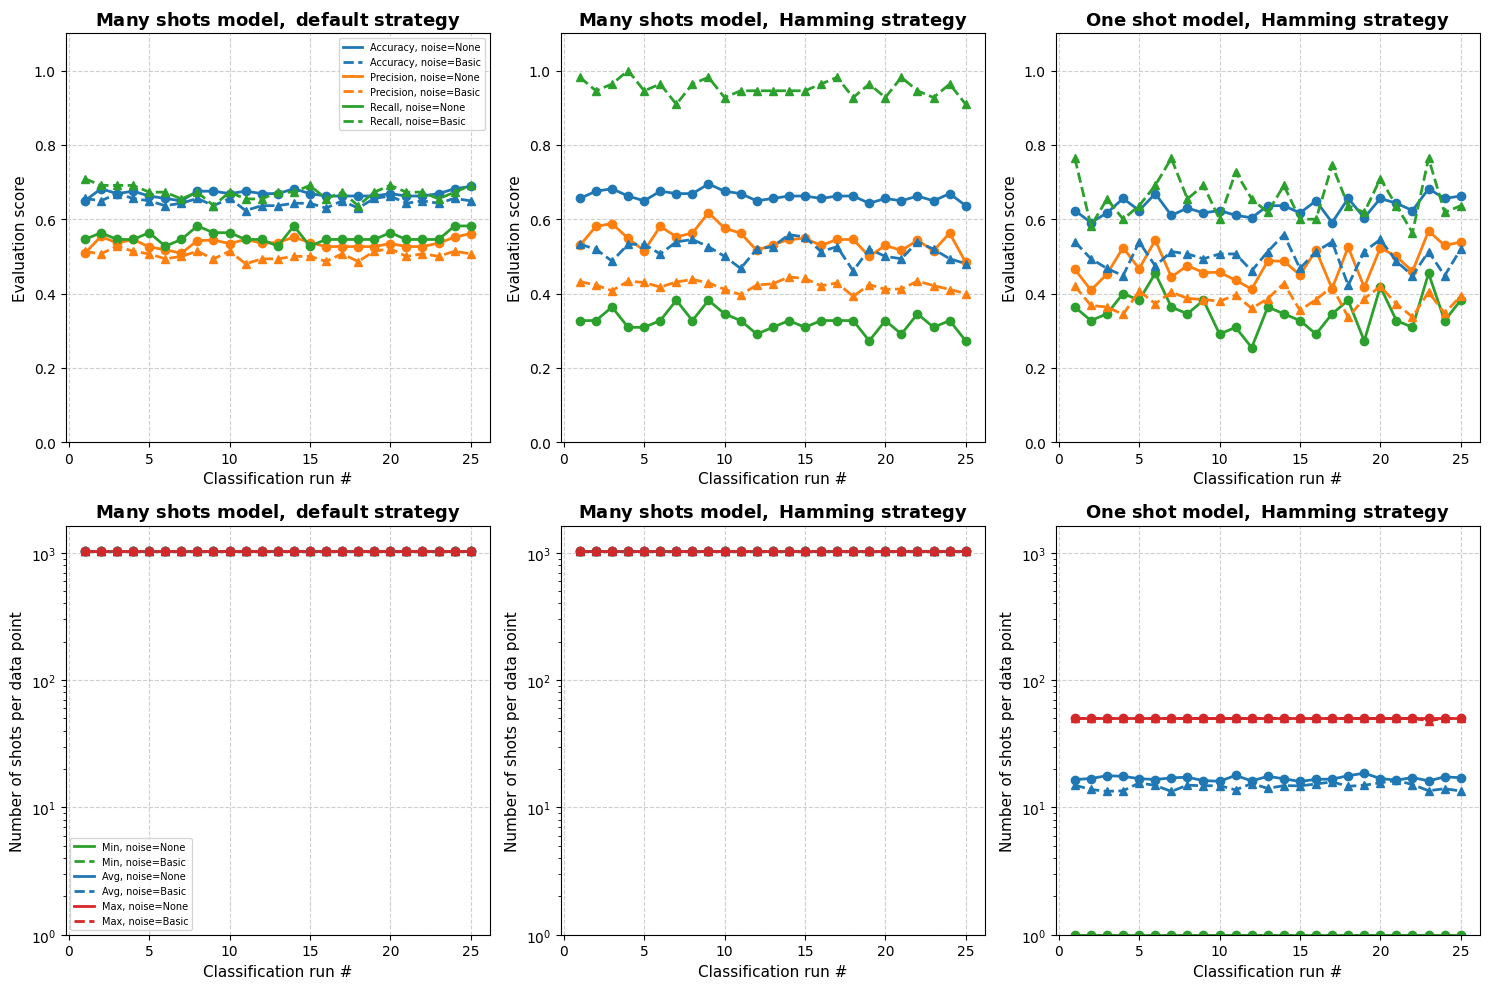

In [66]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

df = df_experiments.copy()

model_names = {
    "X": "Many~shots~model,~default~strategy",
    "Y": "Many~shots~model,~Hamming~strategy",
    "Z": "One~shot~model,~Hamming~strategy"
}

metrics = ["Accuracy", "Precision", "Recall"]
metric_colors = {"Accuracy": "tab:blue", "Precision": "tab:orange", "Recall": "tab:green"}
metric_2_colors = {"Min number of executions": "tab:green", "Avg number of executions": "tab:blue", "Max number of executions": "tab:red"}

models = df["model"].unique()
noise_models = df["noise_model"].unique()
line_styles = ["-", "--", "-.", ":"]  # Different line styles for different noise models
shot_colors = {"Avg": "tab:blue", "Max": "tab:red", "Min": "tab:green"}
noise_models_markers = {"None": "o", "Basic": "^"}

# Create a single figure with 2 rows, columns = number of models
fig, axes = plt.subplots(
    nrows=2,
    ncols=len(models),
    figsize=(5 * len(models), 10),  # double height
    sharex=False,
    sharey=False
)

# Ensure axes is 2D array even if one model
if len(models) == 1:
    axes = axes.reshape(2, 1)

# -----------------------
# First row: Accuracy/Precision/Recall metrics
# -----------------------
for j, model in enumerate(models):
    ax = axes[0, j]

    for k, noise_model in enumerate(noise_models):
        subset = df[(df["model"] == model) & (df["noise_model"] == noise_model)]
        for metric in metrics:
            grouped = subset.groupby("iteration")[metric].agg(["mean", "std"])
            ax.plot(
                grouped.index,
                grouped["mean"],
                label=f"{metric} ({noise_model})",
                color=metric_colors[metric],
                linestyle=line_styles[k % len(line_styles)],
                marker=noise_models_markers[noise_model],
                linewidth=2
            )

    ax.set_title(r"$\bf{" + f"{model_names[model]}" + "}$", fontsize=13)
    ax.set_xlabel("Classification run #", fontsize=11)
    ax.set_ylabel("Evaluation score", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_ylim([0.0, 1.1])

# -----------------------
# Second row: Min/Avg/Max number of executions (log scale)
# -----------------------
for j, model in enumerate(models):
    ax = axes[1, j]

    for k, noise_model in enumerate(noise_models):
        subset = df[(df["model"] == model) & (df["noise_model"] == noise_model)]
        for metric in ["Min number of executions", "Avg number of executions", "Max number of executions"]:
            grouped = subset.groupby("iteration")[metric].agg(["mean", "std"])
            ax.plot(
                grouped.index,
                grouped["mean"],
                label=f"{metric}",
                color=metric_2_colors[metric],
                linestyle=line_styles[k % len(line_styles)],
                marker=noise_models_markers[noise_model],
                linewidth=2
            )
            
        #ax.plot(subset["Min number of executions"], marker=noise_models_markers[noise_model], linestyle='--', color='tab:green', label='Min repetitions')
        #ax.plot(subset["Avg number of executions"], marker=noise_models_markers[noise_model], linestyle='--', color='tab:blue', label='Avg repetitions')
        #ax.plot(subset["Max number of executions"], marker=noise_models_markers[noise_model], linestyle='--', color='tab:red', label='Max repetitions')
    
    ax.set_title(r"$\bf{" + f"{model_names[model]}" + "}$", fontsize=13)
    ax.set_xlabel("Classification run #", fontsize=11)
    ax.set_ylabel("Number of shots per data point", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_yscale("log")
    ax.set_ylim([1, 1628])

# -----------------------
# Legends
# -----------------------
# First row legend
legend_handles = []
for metric in metrics:
    for k, noise_model in enumerate(noise_models):
        legend_handles.append(Line2D([0], [0], color=metric_colors[metric], lw=2,
                                     linestyle=line_styles[k % len(line_styles)], 
                                     label=f"{metric}, noise={noise_model}"))
axes[0, 0].legend(handles=legend_handles, fontsize=7, loc="best")

# Second row legend
legend_handles = []
for stat_type in ["Min", "Avg", "Max"]:
    for k, noise_model in enumerate(noise_models):
        legend_handles.append(Line2D([0], [0], color=shot_colors[stat_type], lw=2,
                                     linestyle=line_styles[k % len(line_styles)], 
                                     label=f"{stat_type}, noise={noise_model}"))
axes[1, 0].legend(handles=legend_handles, fontsize=7, loc="best")

plt.tight_layout()
plt.show()
if save_plot:
    fig.savefig(f"./results/{results_file.split('.')[0]}.fix4.png", dpi=300, bbox_inches="tight")


In [ ]:
# TODO: show difference between accuracy loss - can be interesting for one shot vs others. 

### Statistical analysis

In [98]:
loaded_df_experiments = df_experiments.copy()

In [99]:
loaded_df_experiments.columns

Index(['iteration', 'dataset', 'model', 'noise_model', 'Accuracy', 'Precision',
       'Recall', 'F1', 'ROC AUC', 'Min number of executions',
       'Avg number of executions', 'Max number of executions',
       'Classification time[s]', 'Min time per forward pass[s]',
       'Avg time per forward pass[s]', 'Max time per forward pass[s]'],
      dtype='object')

In [100]:
# 5 qubits
df_experiments_5_q = loaded_df_experiments.copy()
# noiseless
print(f"Noiseless:")
print(f"Model M1:\n", df_experiments_5_q.loc[(df_experiments_5_q["noise_model"] == "None") & (df_experiments_5_q["model"] == "X"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions"]].mean())
print(f"Model M2:\n", df_experiments_5_q.loc[(df_experiments_5_q["noise_model"] == "None") & (df_experiments_5_q["model"] == "Y"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions"]].mean())
print(f"Model M3:\n", df_experiments_5_q.loc[(df_experiments_5_q["noise_model"] == "None") & (df_experiments_5_q["model"] == "Z"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions"]].mean())

# noise
print(f"\nNoise:")
print(f"Model M1:\n", df_experiments_5_q.loc[(df_experiments_5_q["noise_model"] == "Basic") & (df_experiments_5_q["model"] == "X"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions"]].mean())
print(f"Model M2:\n", df_experiments_5_q.loc[(df_experiments_5_q["noise_model"] == "Basic") & (df_experiments_5_q["model"] == "Y"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions"]].mean())
print(f"Model M3:\n", df_experiments_5_q.loc[(df_experiments_5_q["noise_model"] == "Basic") & (df_experiments_5_q["model"] == "Z"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions"]].mean())

Noiseless:
Model M1:
 Accuracy                       0.808421
Precision                      0.823892
Recall                         0.881127
F1                             0.851451
ROC AUC                        0.906446
Avg number of executions    1024.000000
dtype: float64
Model M2:
 Accuracy                       0.838246
Precision                      0.839848
Recall                         0.914930
F1                             0.875726
ROC AUC                        0.906178
Avg number of executions    1024.000000
dtype: float64
Model M3:
 Accuracy                     0.628421
Precision                    0.756884
Recall                       0.593803
F1                           0.664673
ROC AUC                      0.639692
Avg number of executions    17.768772
dtype: float64

Noise:
Model M1:
 Accuracy                       0.654386
Precision                      0.644549
Recall                         0.993239
F1                             0.781728
ROC AUC                 

In [107]:
print(0.838246 - 0.628421)
print(0.625263 - 0.575789)

0.20982500000000004
0.04947400000000002


In [91]:
# 3 qubits
df_experiments_3_q = loaded_df_experiments.copy()
# noiseless
print(f"Noiseless:")
print(f"Model M1:\n", df_experiments_3_q.loc[(df_experiments_3_q["noise_model"] == "None") & (df_experiments_3_q["model"] == "X"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions"]].mean())
print(f"Model M2:\n", df_experiments_3_q.loc[(df_experiments_3_q["noise_model"] == "None") & (df_experiments_3_q["model"] == "Y"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions"]].mean())
print(f"Model M3:\n", df_experiments_3_q.loc[(df_experiments_3_q["noise_model"] == "None") & (df_experiments_3_q["model"] == "Z"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions"]].mean())

# noise
print(f"\nNoise:")
print(f"Model M1:\n", df_experiments_3_q.loc[(df_experiments_3_q["noise_model"] == "Basic") & (df_experiments_3_q["model"] == "X"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions"]].mean())
print(f"Model M2:\n", df_experiments_3_q.loc[(df_experiments_3_q["noise_model"] == "Basic") & (df_experiments_3_q["model"] == "Y"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions"]].mean())
print(f"Model M3:\n", df_experiments_3_q.loc[(df_experiments_3_q["noise_model"] == "Basic") & (df_experiments_3_q["model"] == "Z"), ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Avg number of executions"]].mean())

Noiseless:
Model M1:
 Accuracy                       0.790526
Precision                      0.754565
Recall                         0.983662
F1                             0.854008
ROC AUC                        0.943256
Avg number of executions    1024.000000
dtype: float64
Model M2:
 Accuracy                       0.822456
Precision                      0.781699
Recall                         0.992113
F1                             0.874394
ROC AUC                        0.981461
Avg number of executions    1024.000000
dtype: float64
Model M3:
 Accuracy                    0.760000
Precision                   0.774769
Recall                      0.867606
F1                          0.818289
ROC AUC                     0.724966
Avg number of executions    4.612982
dtype: float64

Noise:
Model M1:
 Accuracy                       0.627368
Precision                      0.625681
Recall                         1.000000
F1                             0.769740
ROC AUC                       

In [79]:
0.822456-0.760000

0.062455999999999956

In [106]:
(1024 * 114)/(3.69 * 114)

277.5067750677507

In [87]:
82.25 - 62.32 

19.93

In [98]:
 0.760000 - 0.551228

0.20877199999999996

In [99]:
0.623158 - 0.551228

0.07192999999999994